# Load Purification Charge-Fluctuation Data

This local CPU notebook discovers the saved `purification_dynamics_maxmix` campaign, loads every completed run, and leaves the results in a compact in-memory `payload` object for interactive follow-up analysis.

## Notebook Scope

This notebook targets the complete `purification_dynamics_maxmix` campaign under `colab_charge_fluctuations/gpu_data/`.

It loads the saved tables and arrays cleanly so later cells can build on them. The notebook now also includes an optional local CPU analysis section that writes derived histogram-video outputs from the already-saved run bundles without rerunning dynamics.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR
while ROOT != ROOT.parent and not (ROOT / 'colab_charge_fluctuations' / 'src').exists():
    ROOT = ROOT.parent
if not (ROOT / 'colab_charge_fluctuations' / 'src').exists():
    raise FileNotFoundError('Could not locate repo root with colab_charge_fluctuations/src')

SRC_DIR = ROOT / 'colab_charge_fluctuations' / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from purification_data_loader import (
    build_run_inventory_table,
    load_all_purification_runs,
    load_purification_campaign,
    resolve_bundle_root,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

BUNDLE_ROOT = resolve_bundle_root(ROOT)
print(f'[repo root] {ROOT}')
print(f'[bundle root] {BUNDLE_ROOT}')
print(f'[src dir] {SRC_DIR}')


[repo root] /home/abhuiyan/class_A_fermionic_adaptive_circuit
[bundle root] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations
[src dir] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/src


## 1. Resolve The Latest Purification Campaign

The loader uses the `gpu_data/index.json` registry and the campaign pointer file. It does not hardcode the campaign id.

In [2]:
campaign = load_purification_campaign(BUNDLE_ROOT)
campaign_manifest = campaign['campaign_manifest']
latest_campaign = campaign['latest_campaign']

print(f"[index path] {campaign['index_path']}")
print(f"[latest campaign path] {campaign['latest_campaign_path']}")
print(f"[campaign manifest path] {campaign['campaign_manifest_path']}")
print(f"[campaign id] {campaign_manifest['campaign_id']}")
print(f"[campaign name] {campaign_manifest['campaign_name']}")
print(f"[recorded run count] {len(campaign_manifest['results'])}")

display(Markdown('### Latest Campaign Pointer'))
display(pd.DataFrame([latest_campaign]))

display(Markdown('### Campaign Configs'))
display(pd.DataFrame(campaign_manifest['configs']))


[index path] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/gpu_data/index.json
[latest campaign path] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/gpu_data/purification_dynamics_maxmix/latest_campaign.json
[campaign manifest path] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/gpu_data/purification_dynamics_maxmix/campaigns/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/campaign_manifest.json
[campaign id] N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny
[campaign name] purification_dynamics_maxmix
[recorded run count] 6


### Latest Campaign Pointer

,campaign_id,campaign_manifest_path,campaign_manifest_path_relative,campaign_name,manifest
0,N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S...,/content/drive/MyDrive/colab_charge_fluctuatio...,purification_dynamics_maxmix/campaigns/N20_mul...,purification_dynamics_maxmix,purification_dynamics_maxmix/campaigns/N20_mul...


### Campaign Configs

,Nx,Ny,batch_size,cycles,init_mode,nshell,perfect_correction,postselect,protocol,protocol_display,samples
0,20,30,NaN,60,maxmix,1,True,False,perfect_correction,perfect_correction,100
1,20,30,1.0,60,maxmix,1,False,True,postselect,post_selection,100
2,20,40,NaN,80,maxmix,1,True,False,perfect_correction,perfect_correction,100
3,20,40,1.0,80,maxmix,1,False,True,postselect,post_selection,100
4,20,50,NaN,100,maxmix,1,True,False,perfect_correction,perfect_correction,100
5,20,50,1.0,100,maxmix,1,False,True,postselect,post_selection,100


## 2. Load All Saved Runs

This eagerly loads the saved CSV and NPZ files for every completed purification run.

In [3]:
payload = load_all_purification_runs(BUNDLE_ROOT)
inventory_df = build_run_inventory_table(payload)

expected_run_count = 6
actual_run_count = len(payload["runs"])

print(f"[loaded runs] {actual_run_count}")
print(f"[run keys] {list(payload['runs'])}")

if actual_run_count != expected_run_count:
    print(
        f"[warning] Expected {expected_run_count} runs, found {actual_run_count}. "
        "Continuing anyway."
    )

display(Markdown("### Run Inventory"))
display(inventory_df)

# Compact overview by protocol / system size.
overview_cols = [
    col for col in ["config_id", "protocol", "Nx", "Ny", "samples_actual", "cycles"]
    if col in inventory_df.columns
]

display(Markdown("### Compact Run Overview"))
display(inventory_df[overview_cols] if overview_cols else inventory_df)


[loaded runs] 6
[run keys] ['N20x30_perfect_correction', 'N20x30_postselect', 'N20x40_perfect_correction', 'N20x40_postselect', 'N20x50_perfect_correction', 'N20x50_postselect']


### Run Inventory

,config_id,Nx,Ny,protocol,samples_actual,cycles,scalar_metrics_bytes,total_entropy_bytes,total_charge_variance_bytes,local_charge_cell_mean_bytes,local_charge_cell_variance_bytes,saved_total_bytes
0,N20x30_perfect_correction,20,30,perfect_correction,100,60,738095,48218,42454,14624427,14371994,29825188
1,N20x30_postselect,20,30,postselect,1,60,6434,2646,2594,100100,100234,212008
2,N20x40_perfect_correction,20,40,perfect_correction,100,80,984709,63593,55602,25779707,25310635,52194246
3,N20x40_postselect,20,40,postselect,1,80,8537,2836,2759,165277,159683,339092
4,N20x50_perfect_correction,20,50,perfect_correction,100,100,1230537,78912,68764,39982411,39256156,80616780
5,N20x50_postselect,20,50,postselect,1,100,10647,3025,2910,246014,231292,493888


### Compact Run Overview

,config_id,protocol,Nx,Ny,samples_actual,cycles
0,N20x30_perfect_correction,perfect_correction,20,30,100,60
1,N20x30_postselect,postselect,20,30,1,60
2,N20x40_perfect_correction,perfect_correction,20,40,100,80
3,N20x40_postselect,postselect,20,40,1,80
4,N20x50_perfect_correction,perfect_correction,20,50,100,100
5,N20x50_postselect,postselect,20,50,1,100


## 3. Per-Run Data Preview

For each run, show:
- the first few rows of `scalar_metrics.csv`
- the available NPZ keys and array shapes
- a quick sanity summary of means and ranges

In [4]:
REQUIRED_ARRAYS = [
    "total_entropy",
    "total_charge_variance",
    "local_charge_cell_mean",
    "local_charge_cell_variance",
]

summary_rows = []

for config_id, run_payload in payload["runs"].items():
    summary = run_payload["summary"]
    metrics_df = run_payload["metrics_df"]
    arrays = run_payload["arrays"]

    display(Markdown(f"### `{config_id}`"))

    basic_info = {
        "protocol": run_payload.get("protocol"),
        "Nx": run_payload.get("Nx"),
        "Ny": run_payload.get("Ny"),
        "samples_actual": summary.get("samples_actual"),
        "cycles": summary.get("cycles"),
        "saved_observables": summary.get("saved_observables"),
    }
    print(json.dumps(basic_info, indent=2))

    display(Markdown("#### `scalar_metrics.csv` head"))
    display(metrics_df.head())

    npz_rows = []
    missing_arrays = []

    for required in REQUIRED_ARRAYS:
        if required not in arrays:
            missing_arrays.append(required)

    for bundle_name, bundle_payload in arrays.items():
        for key, value in bundle_payload.items():
            shape = tuple(value.shape) if hasattr(value, "shape") else ()
            dtype = str(value.dtype) if hasattr(value, "dtype") else type(value).__name__
            npz_rows.append(
                {
                    "bundle": bundle_name,
                    "key": key,
                    "shape": shape,
                    "dtype": dtype,
                }
            )

    display(Markdown("#### NPZ keys and shapes"))
    display(pd.DataFrame(npz_rows))

    if missing_arrays:
        print(f"[warning] Missing arrays for {config_id}: {missing_arrays}")
        continue

    total_entropy = arrays["total_entropy"]["total_entropy"]
    total_charge_variance = arrays["total_charge_variance"]["total_charge_variance"]
    local_charge_cell_mean = arrays["local_charge_cell_mean"]["local_charge_cell_mean"]
    local_charge_cell_variance = arrays["local_charge_cell_variance"]["local_charge_cell_variance"]

    real_space_chern_mean = (
        float(metrics_df["real_space_chern"].mean())
        if "real_space_chern" in metrics_df.columns
        else np.nan
    )

    sanity = {
        "config_id": config_id,
        "protocol": run_payload.get("protocol"),
        "Nx": run_payload.get("Nx"),
        "Ny": run_payload.get("Ny"),
        "samples_actual": summary.get("samples_actual"),
        "cycles": summary.get("cycles"),
        "total_entropy_mean": float(np.nanmean(total_entropy)),
        "total_entropy_min": float(np.nanmin(total_entropy)),
        "total_entropy_max": float(np.nanmax(total_entropy)),
        "total_charge_variance_mean": float(np.nanmean(total_charge_variance)),
        "total_charge_variance_min": float(np.nanmin(total_charge_variance)),
        "total_charge_variance_max": float(np.nanmax(total_charge_variance)),
        "local_charge_cell_mean_mean": float(np.nanmean(local_charge_cell_mean)),
        "local_charge_cell_variance_mean": float(np.nanmean(local_charge_cell_variance)),
        "real_space_chern_mean_from_metrics": real_space_chern_mean,
    }

    summary_rows.append(sanity)

    display(Markdown("#### Quick sanity summary"))
    display(pd.DataFrame([sanity]))

display(Markdown("## All-Run Sanity Summary"))
sanity_df = pd.DataFrame(summary_rows)
display(sanity_df)


### `N20x30_perfect_correction`

{
  "protocol": "perfect_correction",
  "Nx": 20,
  "Ny": 30,
  "samples_actual": 100,
  "cycles": 60,
  "saved_observables": [
    "total_entropy",
    "real_space_chern",
    "total_charge_variance",
    "local_charge_cell_mean",
    "local_charge_cell_variance"
  ]
}


#### `scalar_metrics.csv` head

,config_id,geometry_key,protocol,Nx,Ny,nshell,sample_index,cycle_label,total_entropy,real_space_chern,total_charge_variance
0,N20x30_perfect_correction,N20x30,perfect_correction,20,30,1,0,1,119.794750,0.736021,32.869450
1,N20x30_perfect_correction,N20x30,perfect_correction,20,30,1,0,2,34.431130,0.980133,8.576821
2,N20x30_perfect_correction,N20x30,perfect_correction,20,30,1,0,3,15.666747,0.995577,4.368249
3,N20x30_perfect_correction,N20x30,perfect_correction,20,30,1,0,4,10.121784,0.992875,2.970248
4,N20x30_perfect_correction,N20x30,perfect_correction,20,30,1,0,5,7.361793,0.998811,2.174768


#### NPZ keys and shapes

...

,bundle,key,shape,dtype
0,total_entropy,cycle_labels,"(100,)",int64
1,total_entropy,sample_indices,"(1,)",int64
2,total_entropy,config_json,(),<U837
3,total_entropy,helper_version,(),<U40
4,total_entropy,total_entropy,"(1, 100)",float64
5,total_entropy,formula_total_entropy,(),<U44
6,total_charge_variance,cycle_labels,"(100,)",int64
7,total_charge_variance,sample_indices,"(1,)",int64
8,total_charge_variance,config_json,(),<U837
9,total_charge_variance,helper_version,(),<U40


#### Quick sanity summary

,config_id,protocol,Nx,Ny,samples_actual,cycles,total_entropy_mean,total_entropy_min,total_entropy_max,total_charge_variance_mean,total_charge_variance_min,total_charge_variance_max,local_charge_cell_mean_mean,local_charge_cell_variance_mean,real_space_chern_mean_from_metrics
0,N20x50_postselect,postselect,20,50,1,100,6.394263,1.386597,319.190496,1.82353,0.500022,86.969889,1.0,0.214865,0.996041


## All-Run Sanity Summary

,config_id,protocol,Nx,Ny,samples_actual,cycles,total_entropy_mean,total_entropy_min,total_entropy_max,total_charge_variance_mean,total_charge_variance_min,total_charge_variance_max,local_charge_cell_mean_mean,local_charge_cell_variance_mean,real_space_chern_mean_from_metrics
0,N20x30_perfect_correction,perfect_correction,20,30,100,60,4.082277,0.016247,120.027479,1.140363,0.001904,32.883055,1.002156,0.213023,0.986913
1,N20x30_postselect,postselect,20,30,1,60,6.018385,1.386497,189.007644,1.712157,0.500015,51.429507,1.000000,0.215025,0.993402
2,N20x40_perfect_correction,perfect_correction,20,40,100,80,4.234748,0.020244,160.847923,1.186477,0.002428,44.031444,1.002231,0.212918,0.988276
3,N20x40_postselect,postselect,20,40,1,80,6.233901,1.386556,254.099070,1.775870,0.500019,69.199698,1.000000,0.214925,0.995052
4,N20x50_perfect_correction,perfect_correction,20,50,100,100,4.394082,0.016662,205.421119,1.236558,0.002006,56.323687,1.002109,0.212862,0.986468
5,N20x50_postselect,postselect,20,50,1,100,6.394263,1.386597,319.190496,1.823530,0.500022,86.969889,1.000000,0.214865,0.996041


## 4. Working Objects

The notebook leaves one top-level object named `payload` in memory.

Layout:
- `payload['campaign']`: campaign registry, pointer, and manifest data
- `payload['runs'][config_id]['summary']`: `run_summary.json`
- `payload['runs'][config_id]['metrics_df']`: loaded `scalar_metrics.csv`
- `payload['runs'][config_id]['arrays']['total_entropy']`: dict loaded from `total_entropy.npz`
- `payload['runs'][config_id]['arrays']['total_charge_variance']`: dict loaded from `total_charge_variance.npz`
- `payload['runs'][config_id]['arrays']['local_charge_cell_mean']`: dict loaded from `local_charge_cell_mean.npz`
- `payload['runs'][config_id]['arrays']['local_charge_cell_variance']`: dict loaded from `local_charge_cell_variance.npz`

In [5]:
example_config_id = next(iter(payload['runs']))
example_run = payload['runs'][example_config_id]

print(f'[example config] {example_config_id}')
print(f"[summary keys] {sorted(example_run['summary'].keys())[:12]} ...")
print(f"[metrics columns] {example_run['metrics_df'].columns.tolist()}")
print(
    '[total_entropy array shape]',
    example_run['arrays']['total_entropy']['total_entropy'].shape,
)
print(
    '[local_charge_cell_variance array shape]',
    example_run['arrays']['local_charge_cell_variance']['local_charge_cell_variance'].shape,
)


[example config] N20x30_perfect_correction
[summary keys] ['Nx', 'Ny', 'alpha_1', 'alpha_2', 'backend', 'batch_size', 'batch_size_auto_info', 'batch_size_mode', 'batch_size_requested', 'canonical_dynamics_entry_point', 'covariance_history_saved', 'cycles'] ...
[metrics columns] ['config_id', 'geometry_key', 'protocol', 'Nx', 'Ny', 'nshell', 'sample_index', 'cycle_label', 'total_entropy', 'real_space_chern', 'total_charge_variance']
[total_entropy array shape] (100, 60)
[local_charge_cell_variance array shape] (100, 60, 20, 30)


## 5. Centered Total-Charge Histogram Video

This optional section selects the three `perfect_correction` runs, reconstructs the centered total charge from the saved `local_charge_cell_mean` arrays, writes an MP4 histogram comparison video, and saves raw and percent-normalized sample-statistics sidecars.

In [6]:
# --------------------------------------------------------------------
# Analysis toggles
# --------------------------------------------------------------------
RUN_CENTERED_CHARGE_HISTOGRAM_VIDEO = True
RUN_CENTERED_CHARGE_VARIANCE_FIGURES = True
RUN_REAL_SPACE_CHERN_FIGURE = True
RUN_TOTAL_ENTROPY_FIGURE = True
RUN_EXPECTED_CHARGE_HEATMAP_VIDEO = True

RUN_TOTAL_CHARGE_VARIANCE_HISTOGRAM_VIDEO = True
RUN_TOTAL_CHARGE_VARIANCE_SUMMARY_FIGURES = True
RUN_SPATIAL_CHARGE_VARIANCE_HEATMAP_VIDEO = True

RUN_ROLLING_AVERAGE_OVERLAY_FIGURES = True
RUN_NY_ROLLING_AVERAGE_SCALING_FIGURE = True

WRITE_MANIFESTS = True
DISPLAY_ARTIFACTS = True

# Optional: restrict to selected config ids.
# Set to None to use everything selected by the analysis helper functions.
SELECTED_CONFIG_IDS = None
# Example:
# SELECTED_CONFIG_IDS = ["perfect_correction_Lx8", "perfect_correction_Lx12"]

# Rolling-average controls.
ROLLING_AVERAGE_WINDOW = 5
ROLLING_AVERAGE_MIN_PERIODS = 1
ROLLING_AVERAGE_CENTER = True

# Cycles to use in the Ny scaling figure.
# The nearest available cycle is used if an exact cycle is not present.
NY_SCALING_TARGET_CYCLES = [5, 10, 20, 50]


In [7]:
from IPython.display import Image, Video

import importlib
import purification_total_charge_histogram_video as pthv

pthv = importlib.reload(pthv)

ANALYSIS_NAME = pthv.ANALYSIS_NAME
compute_centered_total_charge_sample_stats = pthv.compute_centered_total_charge_sample_stats
compute_total_charge_variance_sample_stats = pthv.compute_total_charge_variance_sample_stats
make_centered_total_charge_histogram_video = pthv.make_centered_total_charge_histogram_video
make_centered_total_charge_variance_figures = pthv.make_centered_total_charge_variance_figures
make_real_space_chern_loglog_figure = pthv.make_real_space_chern_loglog_figure
make_sample_averaged_expected_charge_video = pthv.make_sample_averaged_expected_charge_video
make_sample_averaged_spatial_charge_variance_video = pthv.make_sample_averaged_spatial_charge_variance_video
make_total_entropy_loglog_figure = pthv.make_total_entropy_loglog_figure
make_total_charge_variance_histogram_video = pthv.make_total_charge_variance_histogram_video
make_total_charge_variance_summary_figures = pthv.make_total_charge_variance_summary_figures
prepare_centered_total_charge_histogram_records = pthv.prepare_centered_total_charge_histogram_records
prepare_real_space_chern_records = pthv.prepare_real_space_chern_records
prepare_total_entropy_records = pthv.prepare_total_entropy_records
prepare_total_charge_variance_histogram_records = pthv.prepare_total_charge_variance_histogram_records
write_centered_total_charge_analysis_manifest = pthv.write_centered_total_charge_analysis_manifest
write_total_charge_variance_analysis_manifest = pthv.write_total_charge_variance_analysis_manifest


def filter_records(records, selected_config_ids=None):
    if selected_config_ids is None:
        return records
    selected_config_ids = set(selected_config_ids)
    return [record for record in records if record["config_id"] in selected_config_ids]


centered_charge_records = prepare_centered_total_charge_histogram_records(payload=payload)
real_space_chern_records = prepare_real_space_chern_records(payload=payload)
total_entropy_records = prepare_total_entropy_records(payload=payload)
total_charge_variance_records = prepare_total_charge_variance_histogram_records(payload=payload)

centered_charge_records = filter_records(centered_charge_records, SELECTED_CONFIG_IDS)
real_space_chern_records = filter_records(real_space_chern_records, SELECTED_CONFIG_IDS)
total_entropy_records = filter_records(total_entropy_records, SELECTED_CONFIG_IDS)
total_charge_variance_records = filter_records(total_charge_variance_records, SELECTED_CONFIG_IDS)

centered_charge_stats_df = compute_centered_total_charge_sample_stats(centered_charge_records)
total_charge_variance_stats_df = compute_total_charge_variance_sample_stats(total_charge_variance_records)

campaign_id = payload["campaign"]["campaign_manifest"]["campaign_id"]

analysis_root = BUNDLE_ROOT / "analysis_outputs" / ANALYSIS_NAME / campaign_id
figure_root = analysis_root / "figures"

variance_analysis_root = (
    BUNDLE_ROOT
    / "analysis_outputs"
    / "purification_total_charge_variance_histogram_video_cpu"
    / campaign_id
)
variance_figure_root = variance_analysis_root / "figures"

display(Markdown("### Selected Centered-Charge Runs"))
display(
    pd.DataFrame(
        [
            {
                "config_id": record["config_id"],
                "Nx": record["Nx"],
                "Ny": record["Ny"],
                "samples_actual": record["samples_actual"],
                "cycles": record["cycles"],
                "q_raw_shape": record["q_raw"].shape,
                "q_pct_shape": record["q_pct"].shape,
            }
            for record in centered_charge_records
        ]
    )
)

display(Markdown("### Selected Total-Charge-Variance Runs"))
display(
    pd.DataFrame(
        [
            {
                "config_id": record["config_id"],
                "Nx": record["Nx"],
                "Ny": record["Ny"],
                "samples_actual": record["samples_actual"],
                "cycles": record["cycles"],
            }
            for record in total_charge_variance_records
        ]
    )
)

print(f"[analysis root] {analysis_root}")
print(f"[variance analysis root] {variance_analysis_root}")

display(Markdown("### Centered-Charge Sample-Statistics Table Preview"))
display(centered_charge_stats_df.head())

display(Markdown("### Total-Charge-Variance Sample-Statistics Table Preview"))
display(total_charge_variance_stats_df.head())

def display_image_if_exists(title, path):
    if path is None:
        return
    path = Path(path)
    if path.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))
    else:
        print(f"[missing image] {title}: {path}")


def display_video_if_exists(title, path):
    if path is None:
        return
    path = Path(path)
    if path.exists():
        display(Markdown(f"### {title}"))
        display(
            Video(
                filename=str(path),
                embed=False,
                html_attributes='controls preload="metadata" style="width:100%; max-width:1100px;"',
            )
        )
    else:
        print(f"[missing video] {title}: {path}")


### Selected Centered-Charge Runs

,config_id,Nx,Ny,samples_actual,cycles,q_raw_shape,q_pct_shape
0,N20x30_perfect_correction,20,30,100,60,"(100, 60)","(100, 60)"
1,N20x40_perfect_correction,20,40,100,80,"(100, 80)","(100, 80)"
2,N20x50_perfect_correction,20,50,100,100,"(100, 100)","(100, 100)"


### Selected Total-Charge-Variance Runs

,config_id,Nx,Ny,samples_actual,cycles
0,N20x30_perfect_correction,20,30,100,60
1,N20x40_perfect_correction,20,40,100,80
2,N20x50_perfect_correction,20,50,100,100


[analysis root] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_total_charge_histogram_video_cpu/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny
[variance analysis root] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_total_charge_variance_histogram_video_cpu/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny


### Centered-Charge Sample-Statistics Table Preview

,config_id,Nx,Ny,protocol,cycle_label,sample_count,centered_total_charge_raw_sample_mean,centered_total_charge_raw_sample_variance,centered_total_charge_raw_sample_stdev,centered_total_charge_percent_sample_mean,centered_total_charge_percent_sample_variance,centered_total_charge_percent_sample_stdev
0,N20x30_perfect_correction,20,30,perfect_correction,1,100,2.576117,10.721514,3.274372,0.214676,0.074455,0.272864
1,N20x30_perfect_correction,20,30,perfect_correction,2,100,2.831046,13.058490,3.613653,0.235920,0.090684,0.301138
2,N20x30_perfect_correction,20,30,perfect_correction,3,100,2.742523,23.328446,4.829953,0.228544,0.162003,0.402496
3,N20x30_perfect_correction,20,30,perfect_correction,4,100,3.686384,22.875606,4.782845,0.307199,0.158858,0.398570
4,N20x30_perfect_correction,20,30,perfect_correction,5,100,3.068372,21.539275,4.641042,0.255698,0.149578,0.386754


### Total-Charge-Variance Sample-Statistics Table Preview

,config_id,Nx,Ny,protocol,cycle_label,sample_count,total_charge_variance_raw_sample_mean,total_charge_variance_raw_sample_variance,total_charge_variance_raw_sample_stdev,total_charge_variance_percent_sample_mean,total_charge_variance_percent_sample_variance,total_charge_variance_percent_sample_stdev
0,N20x30_perfect_correction,20,30,perfect_correction,1,100,31.060234,0.707509,0.841135,10.353411,0.078612,0.280378
1,N20x30_perfect_correction,20,30,perfect_correction,2,100,8.115137,0.092748,0.304545,2.705046,0.010305,0.101515
2,N20x30_perfect_correction,20,30,perfect_correction,3,100,4.351212,0.137721,0.371108,1.450404,0.015302,0.123703
3,N20x30_perfect_correction,20,30,perfect_correction,4,100,2.909342,0.065830,0.256573,0.969781,0.007314,0.085524
4,N20x30_perfect_correction,20,30,perfect_correction,5,100,2.131638,0.026990,0.164286,0.710546,0.002999,0.054762


### Centered Total-Charge Histogram Comparison Video

### Centered Total-Charge Final Frame

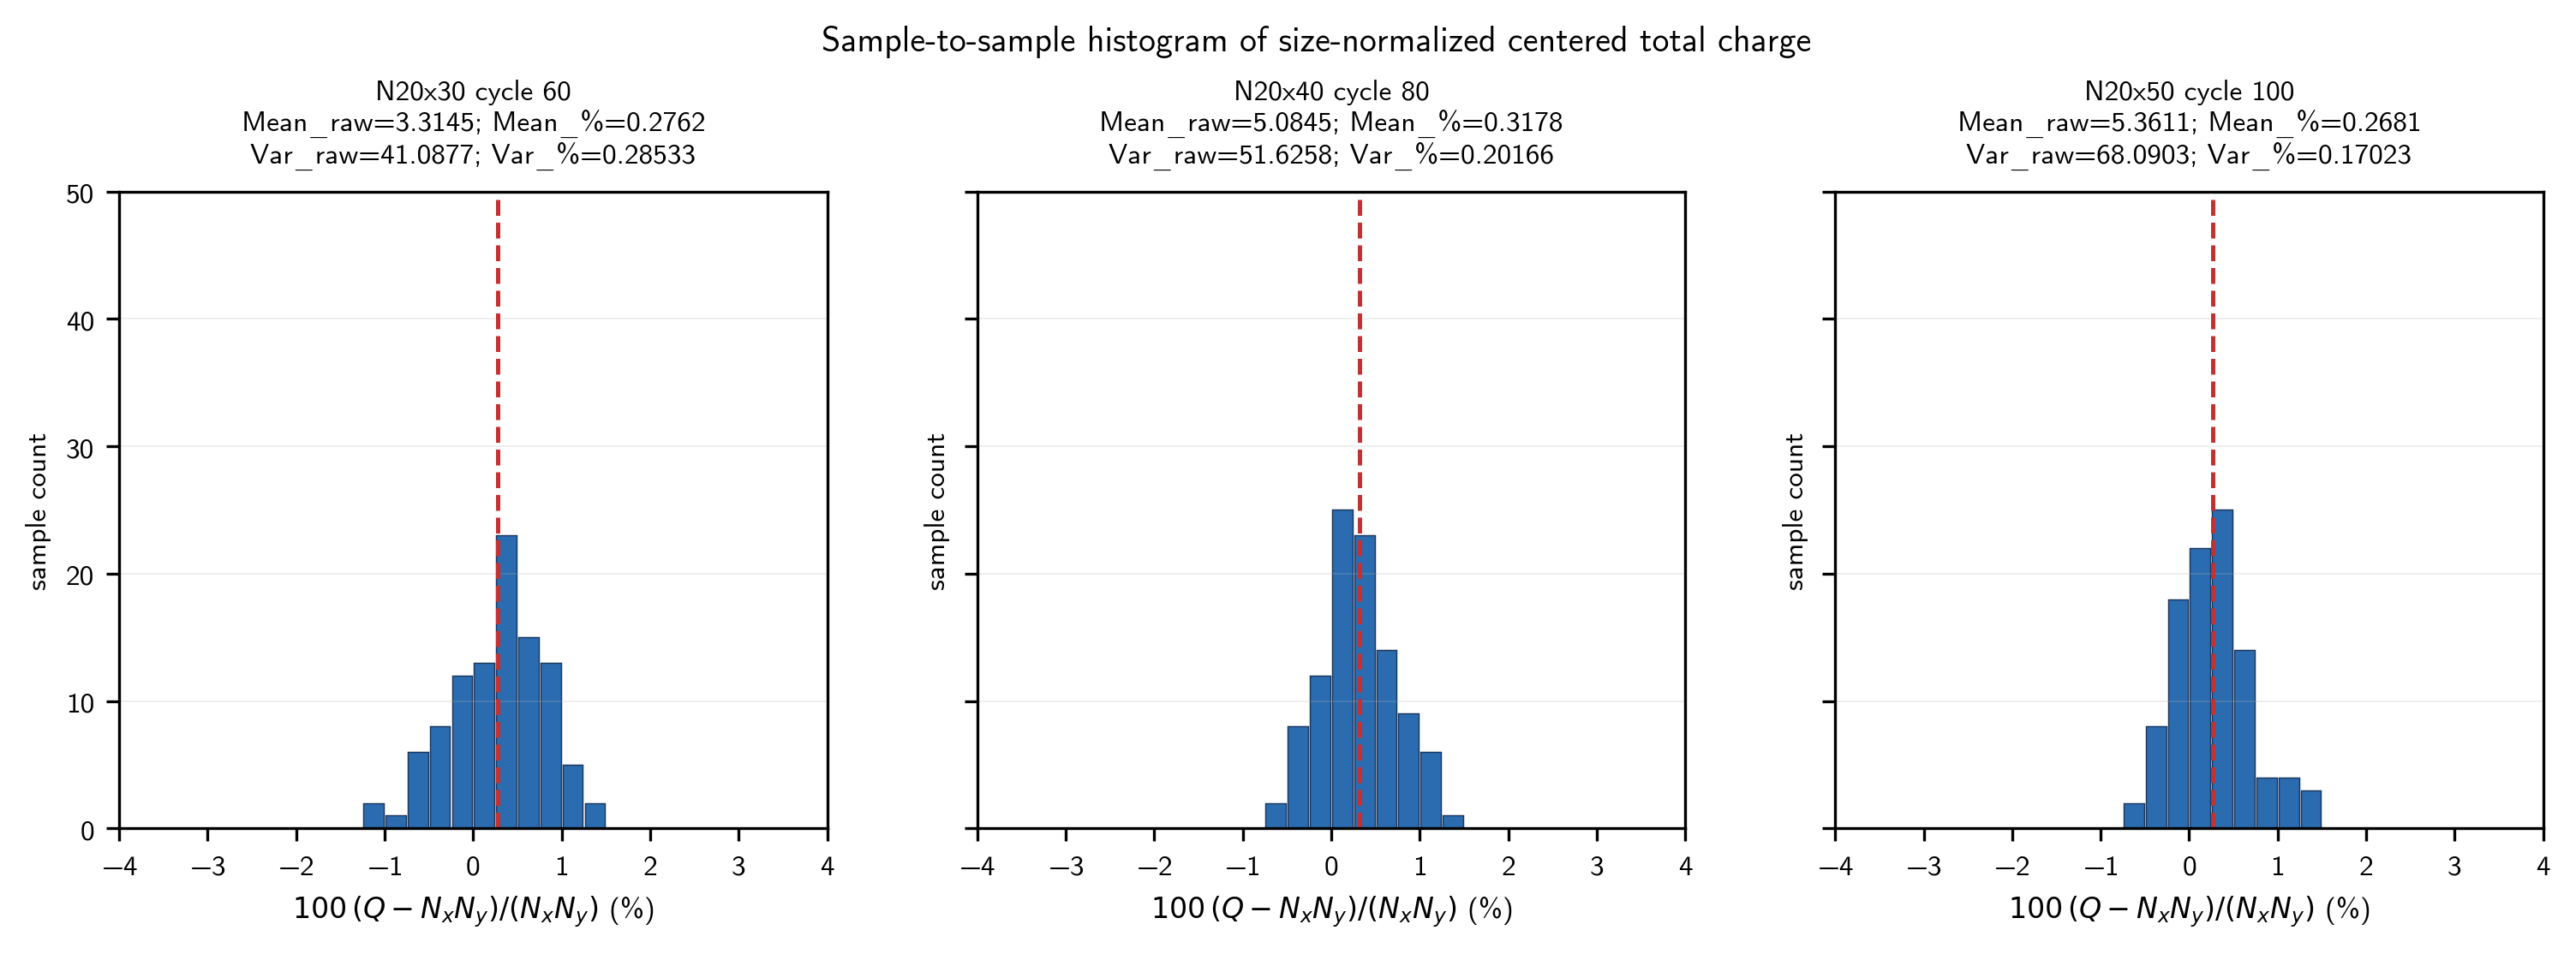

### Centered-Charge Raw Mean Vs Cycle

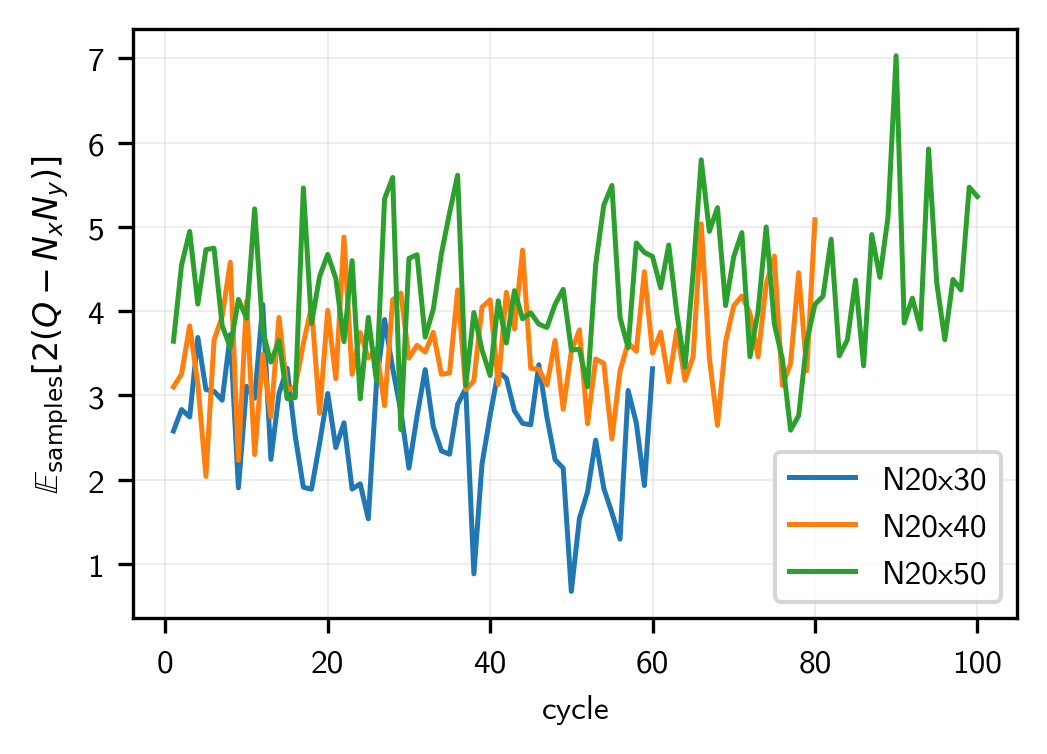

### Centered-Charge Raw Mean With Sample Stdev Vs Cycle

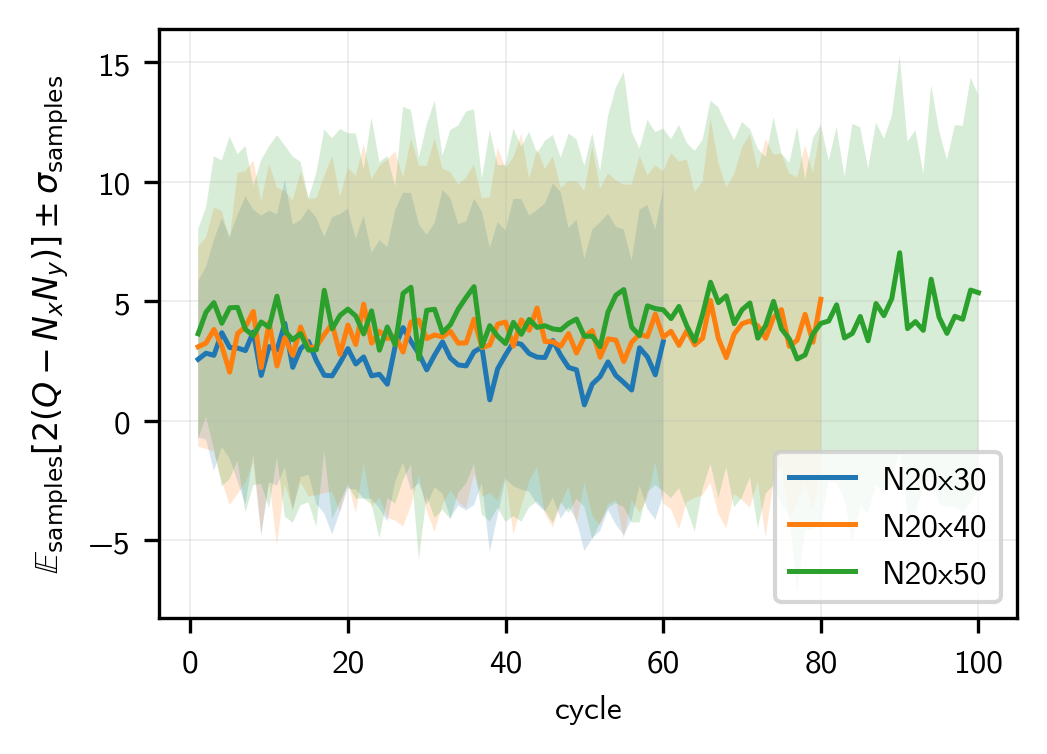

### Centered-Charge Percent Mean Vs Cycle

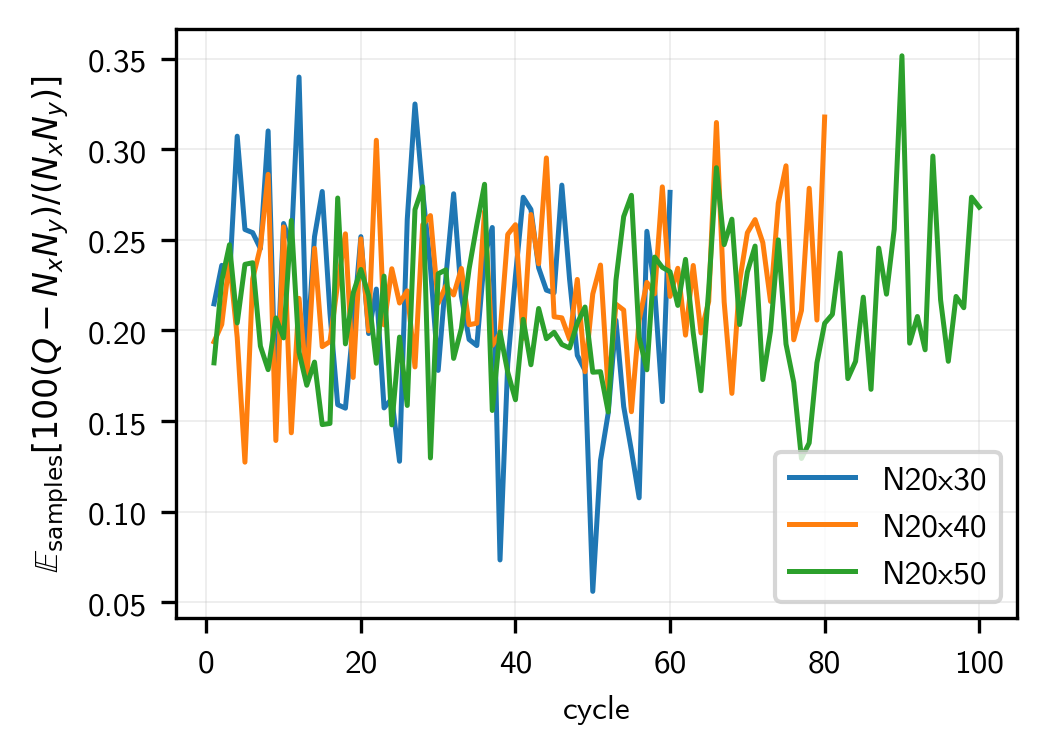

### Centered-Charge Percent Mean With Sample Stdev Vs Cycle

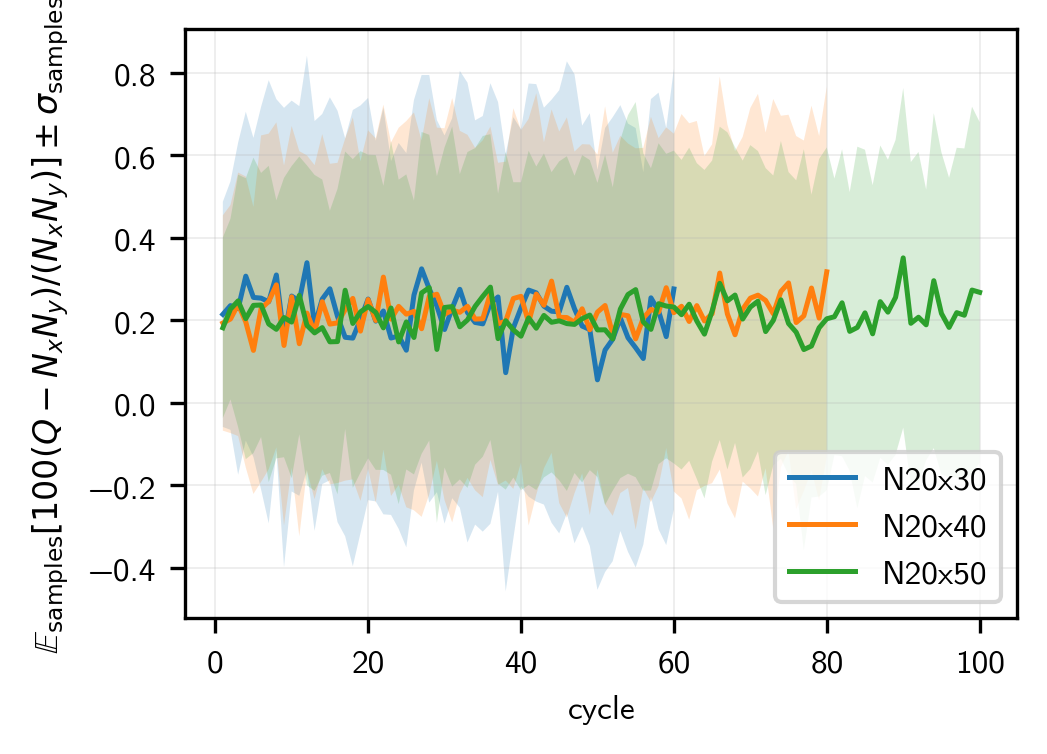

### Centered-Charge Raw Variance Vs Cycle

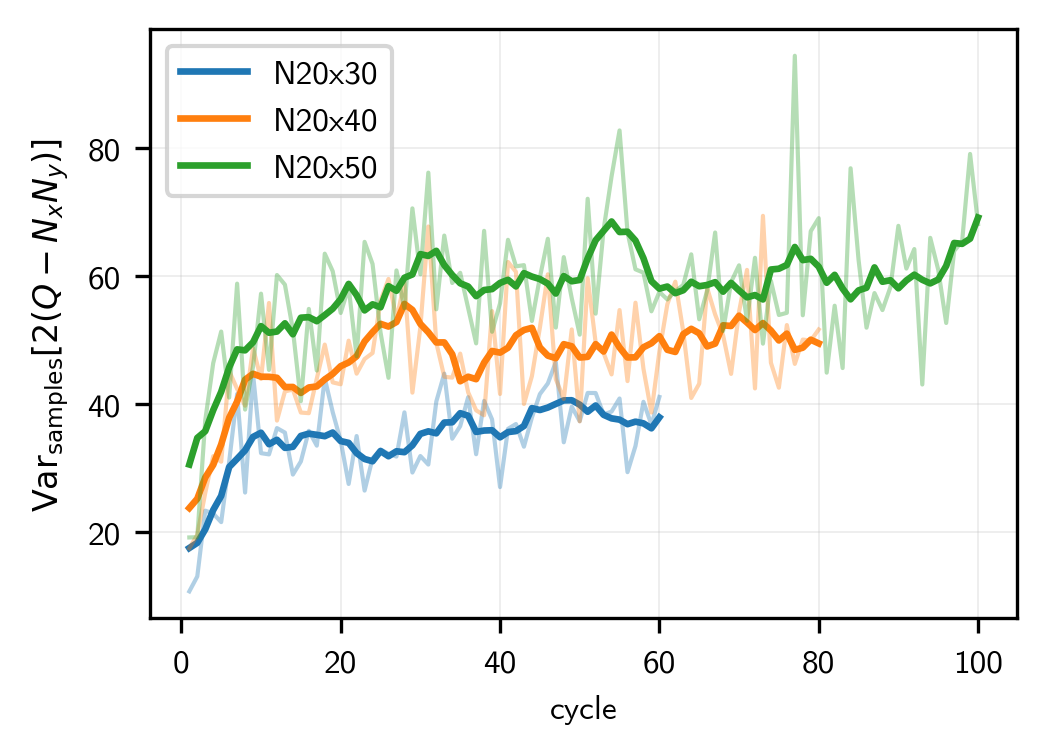

### Centered-Charge Percent Variance Vs Cycle

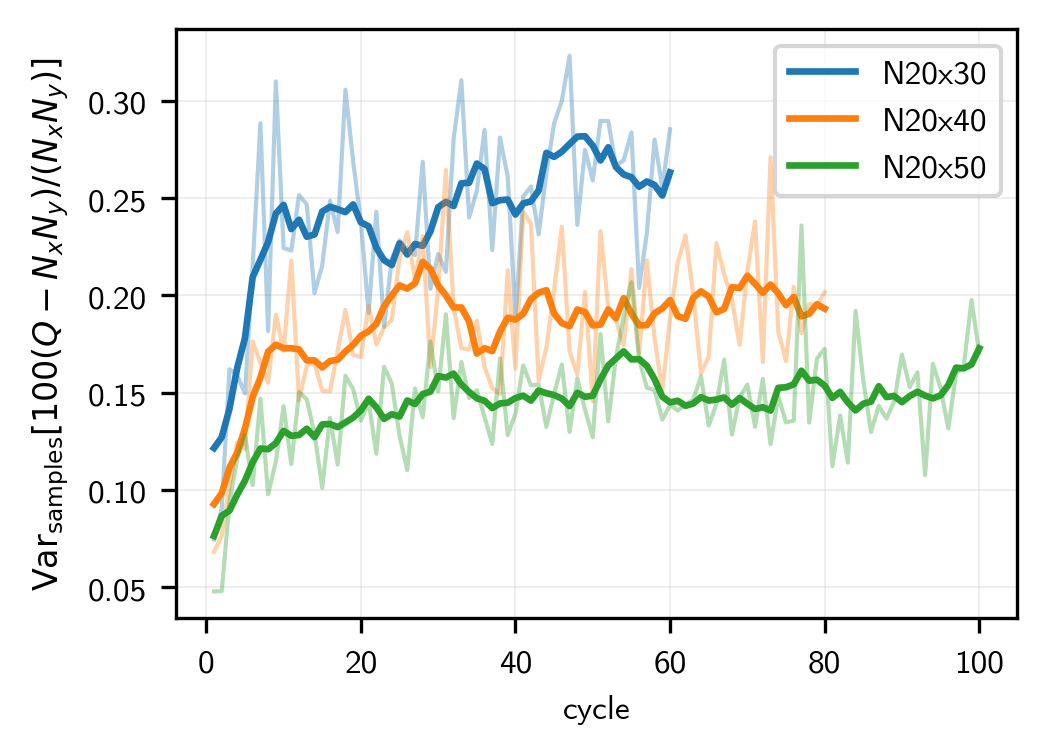

### Sample-Averaged Real-Space Chern Number Vs Cycle Log-Log

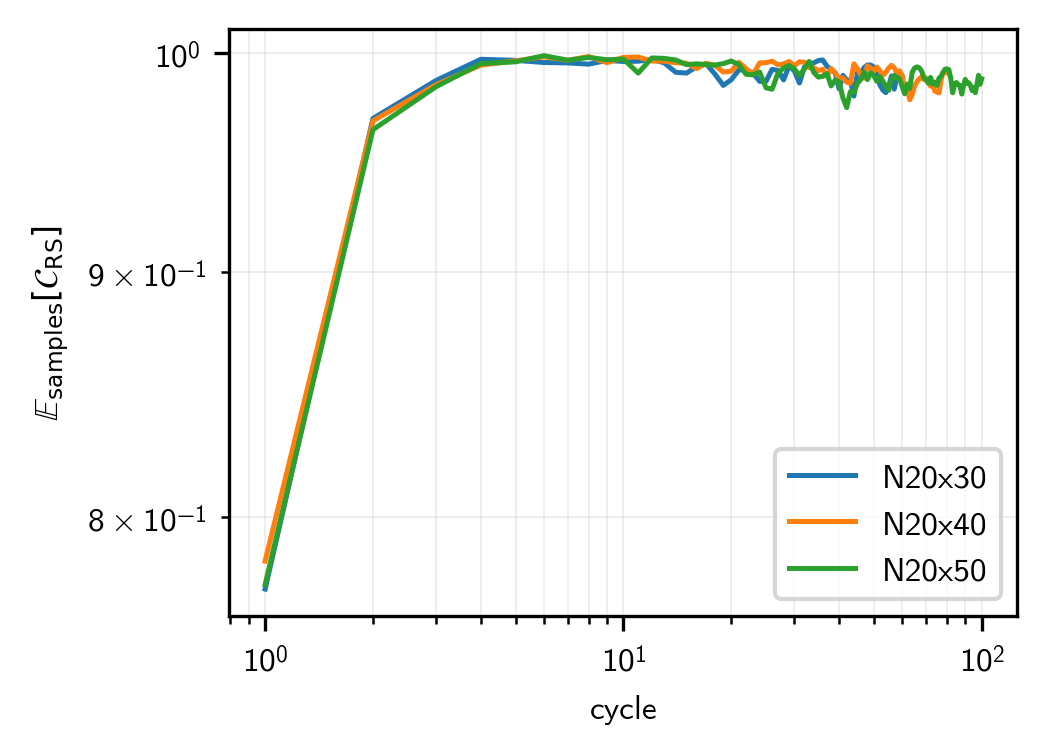

### Sample-Averaged Total Entropy Vs Cycle Log-Log

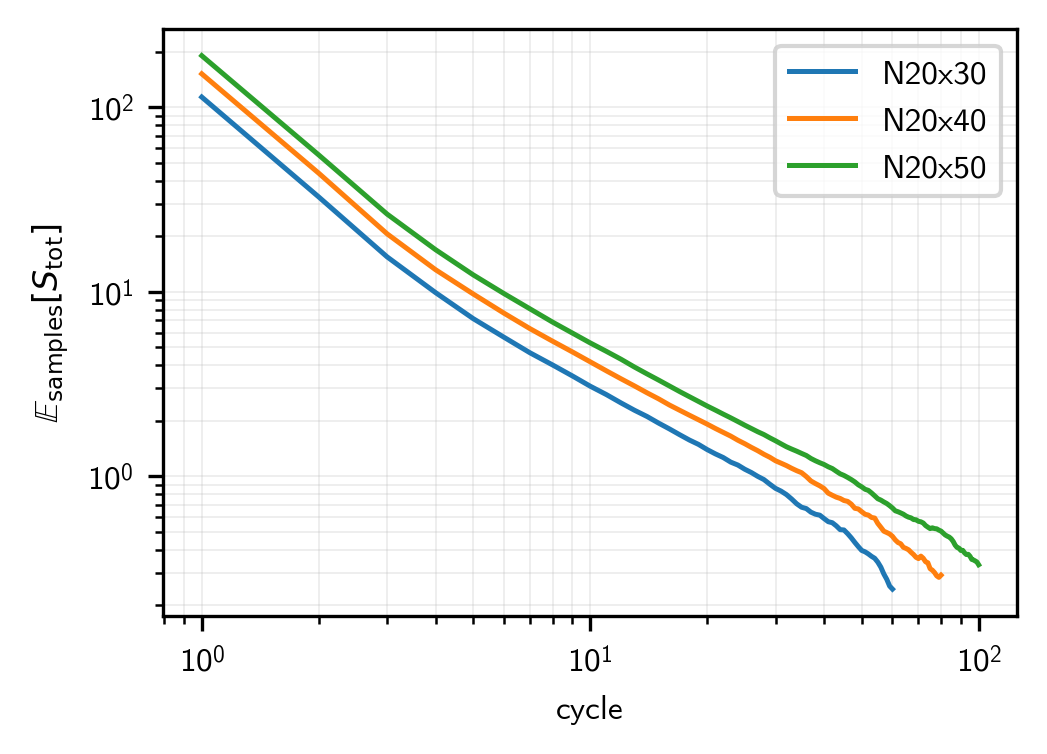

### Sample-Averaged Total Entropy With Sample Stdev Vs Cycle Log-Log

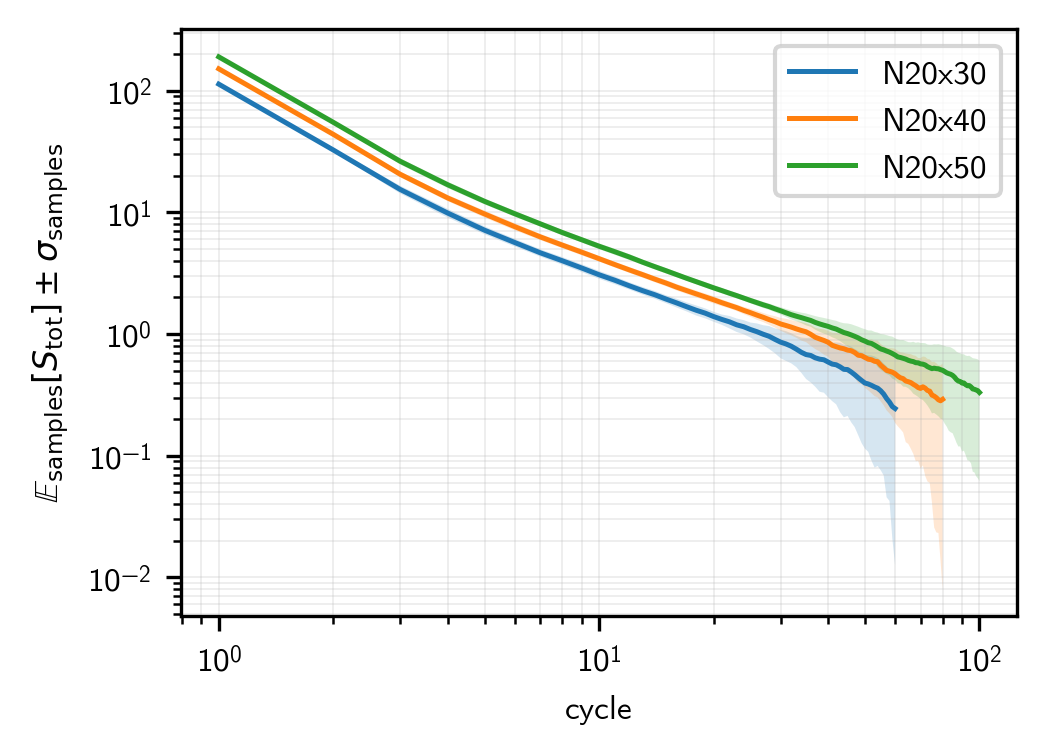

### Sample-Averaged Expected Charge Heatmap Video

### Sample-Averaged Expected Charge Final Frame

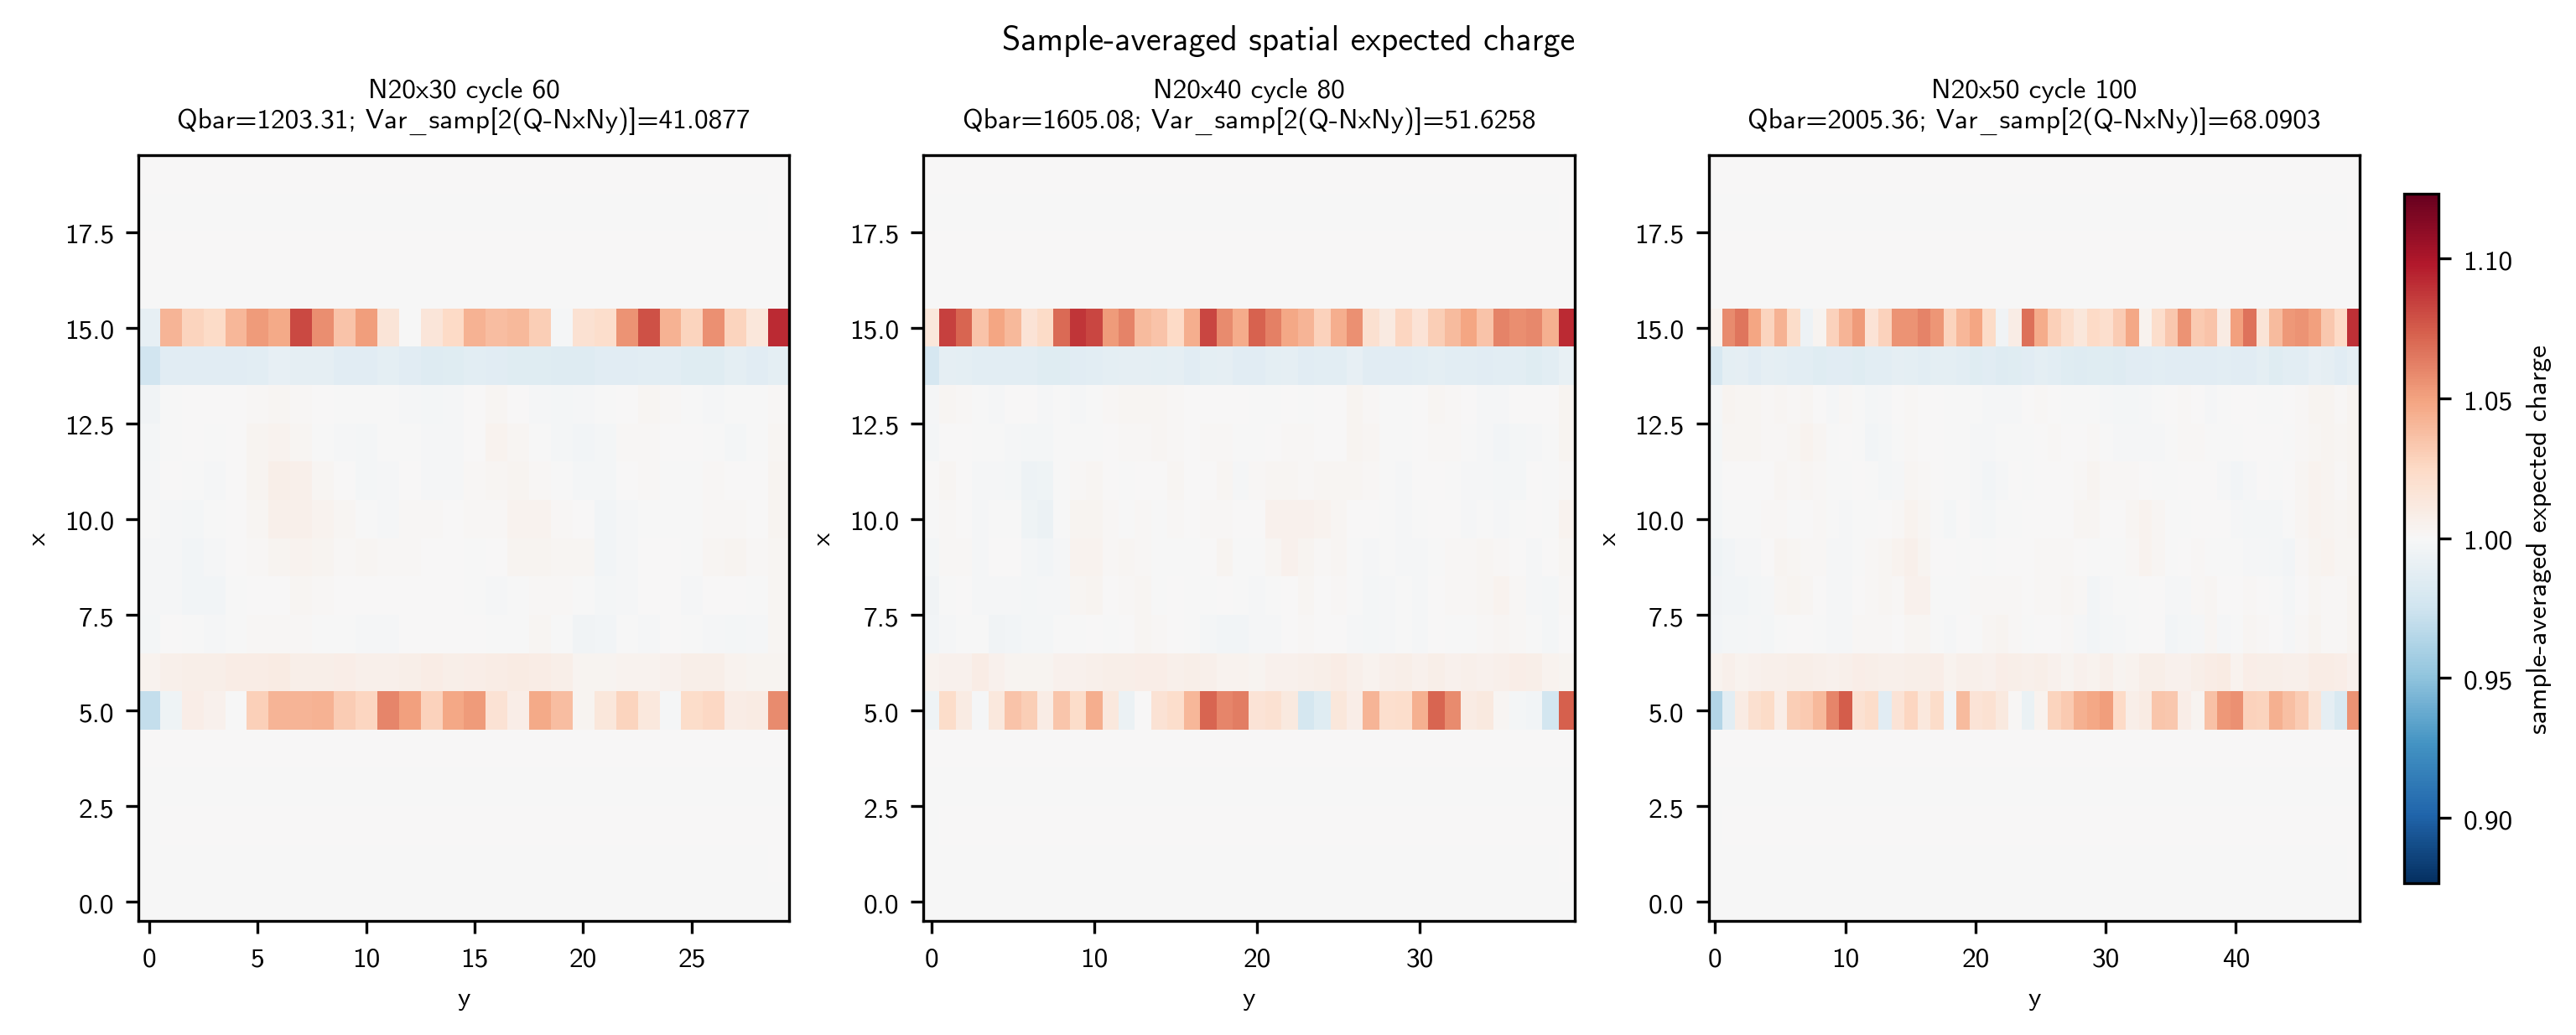

### Saved Centered-Charge Sample-Statistics Table

,config_id,Nx,Ny,protocol,cycle_label,sample_count,centered_total_charge_raw_sample_mean,centered_total_charge_raw_sample_variance,centered_total_charge_raw_sample_stdev,centered_total_charge_percent_sample_mean,centered_total_charge_percent_sample_variance,centered_total_charge_percent_sample_stdev
0,N20x30_perfect_correction,20,30,perfect_correction,1,100,2.576117,10.721514,3.274372,0.214676,0.074455,0.272864
1,N20x30_perfect_correction,20,30,perfect_correction,2,100,2.831046,13.058490,3.613653,0.235920,0.090684,0.301138
2,N20x30_perfect_correction,20,30,perfect_correction,3,100,2.742523,23.328446,4.829953,0.228544,0.162003,0.402496
3,N20x30_perfect_correction,20,30,perfect_correction,4,100,3.686384,22.875606,4.782845,0.307199,0.158858,0.398570
4,N20x30_perfect_correction,20,30,perfect_correction,5,100,3.068372,21.539275,4.641042,0.255698,0.149578,0.386754
5,N20x30_perfect_correction,20,30,perfect_correction,6,100,3.047486,30.953037,5.563545,0.253957,0.214952,0.463629
6,N20x30_perfect_correction,20,30,perfect_correction,7,100,2.941867,41.537950,6.444994,0.245156,0.288458,0.537083
7,N20x30_perfect_correction,20,30,perfect_correction,8,100,3.721348,26.157271,5.114418,0.310112,0.181648,0.426201
8,N20x30_perfect_correction,20,30,perfect_correction,9,100,1.901522,44.630781,6.680627,0.158460,0.309936,0.556719
9,N20x30_perfect_correction,20,30,perfect_correction,10,100,3.108234,32.307428,5.683962,0.259020,0.224357,0.473664


### Total-Charge-Variance Histogram Comparison Video

### Total-Charge-Variance Final Frame

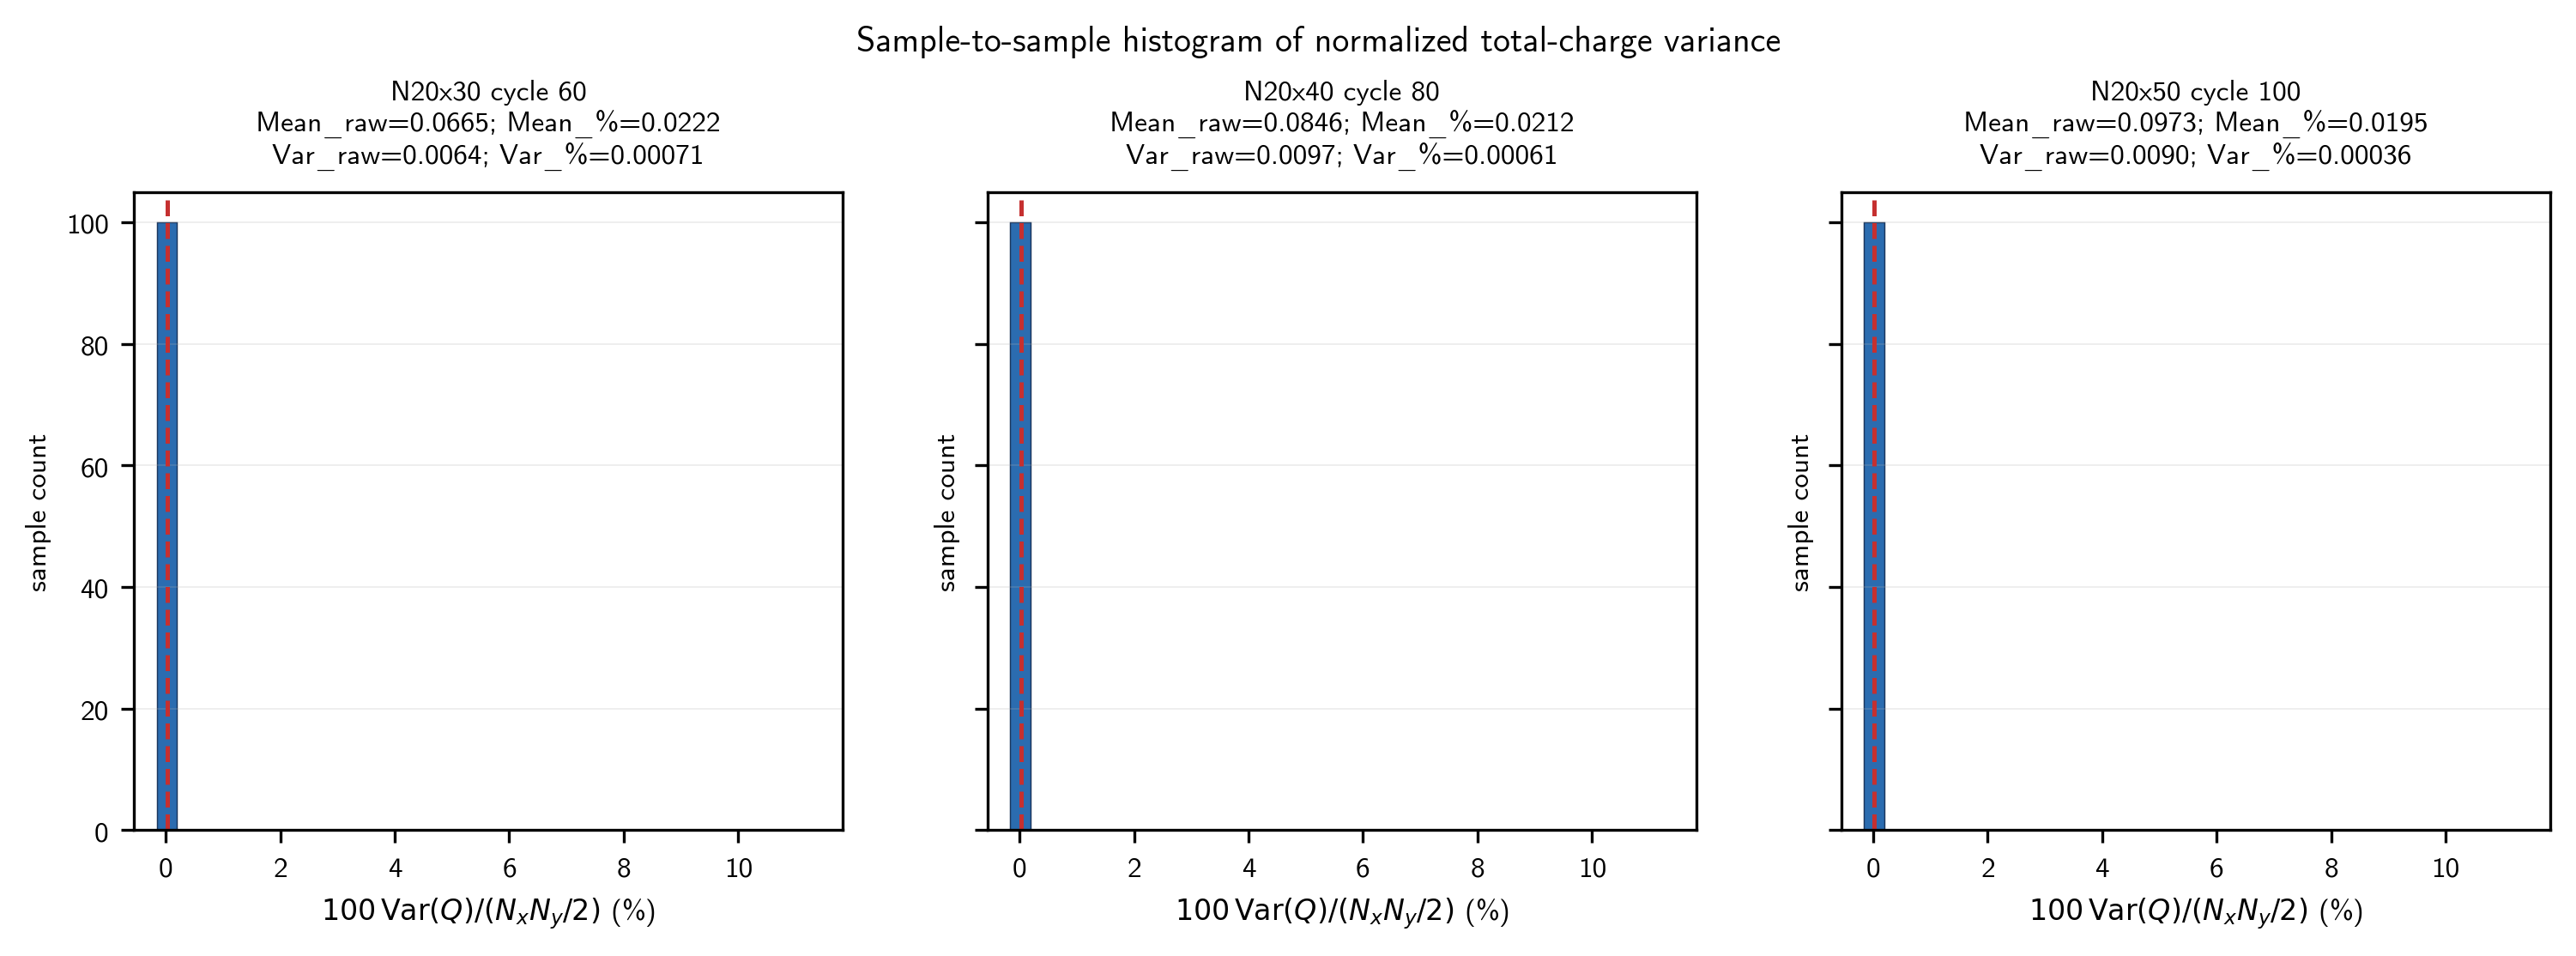

### Total-Charge-Variance Raw Mean Vs Cycle

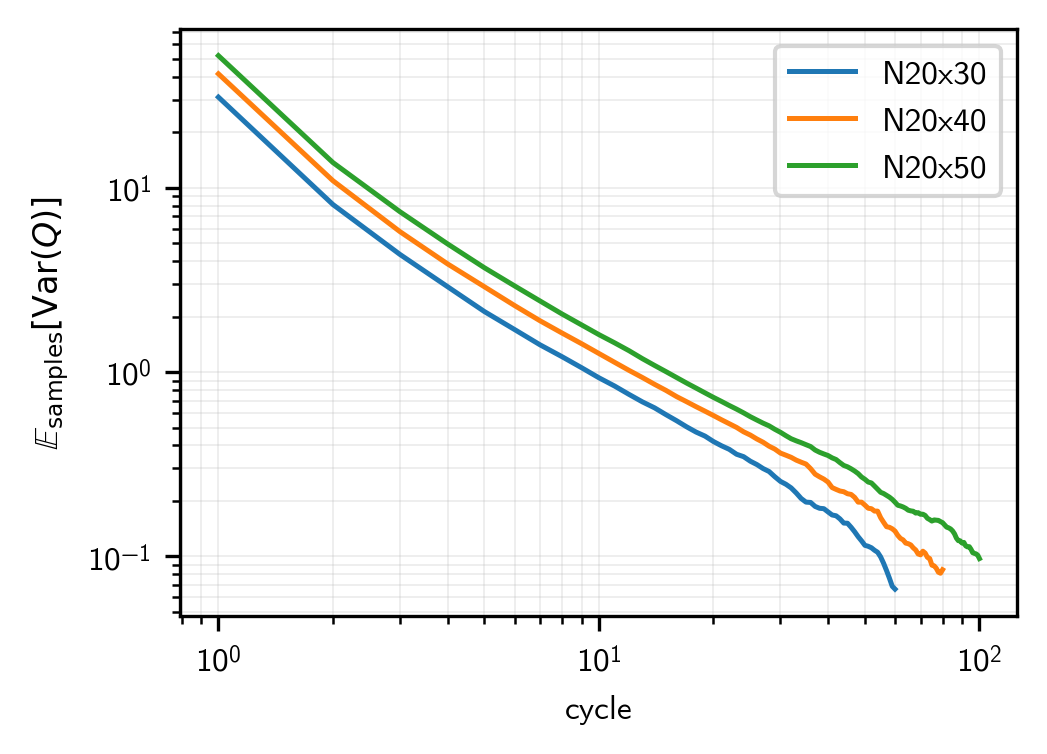

### Total-Charge-Variance Raw Mean With Sample Stdev Vs Cycle

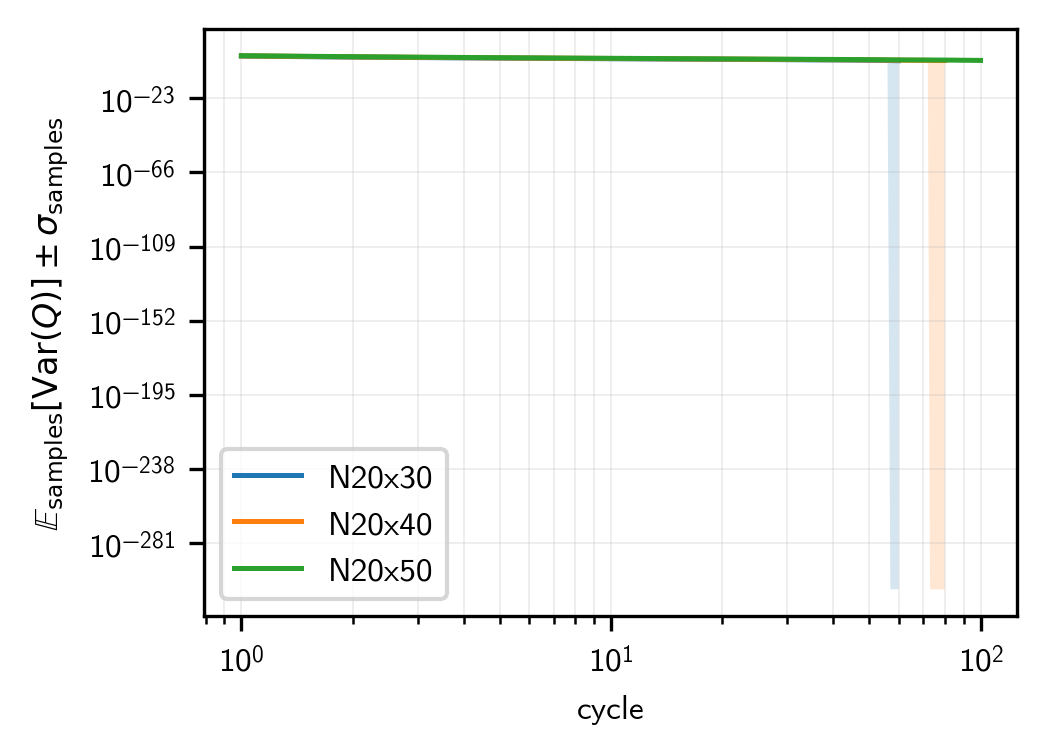

### Total-Charge-Variance Percent Mean Vs Cycle

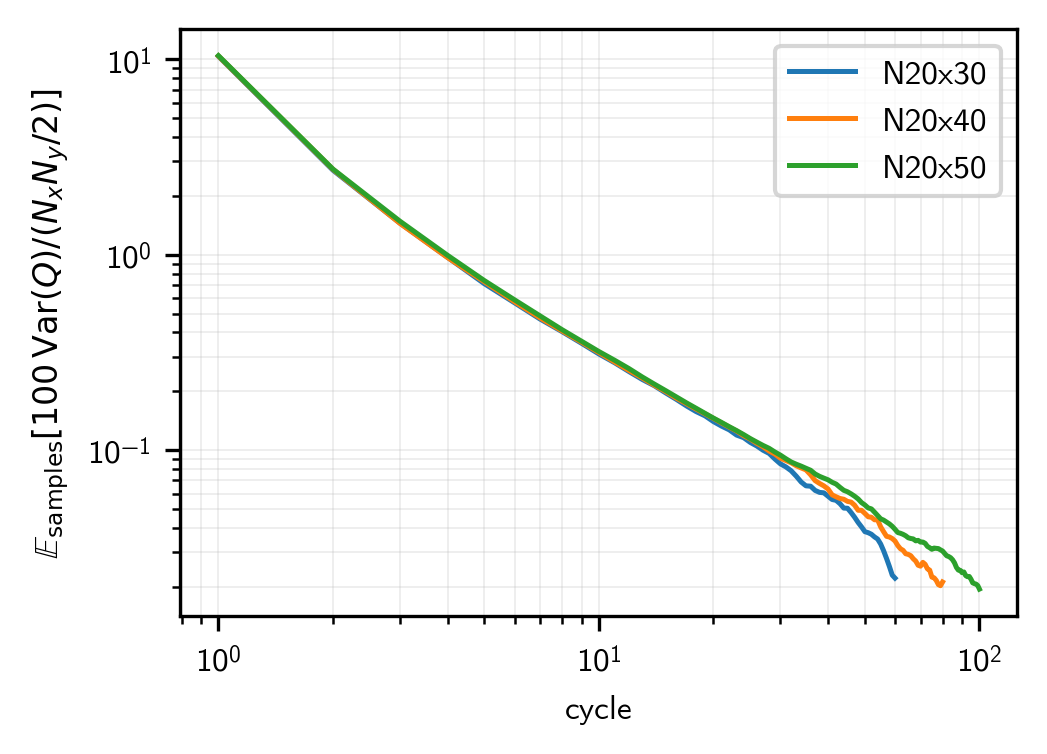

### Total-Charge-Variance Percent Mean With Sample Stdev Vs Cycle

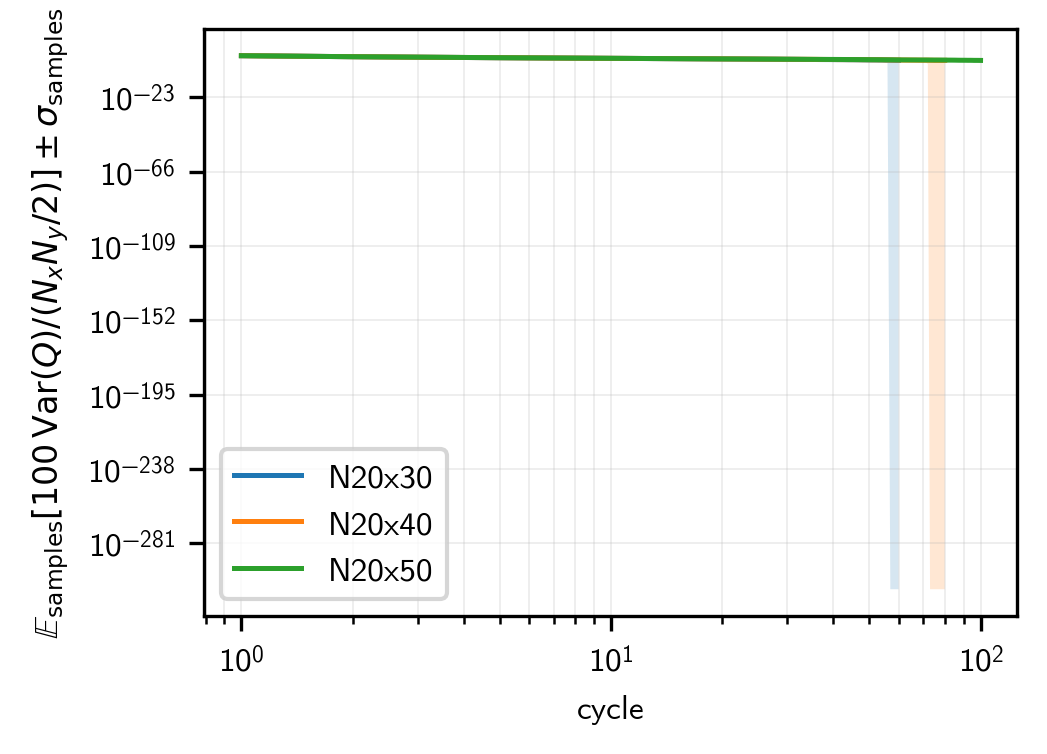

### Total-Charge-Variance Raw Variance Vs Cycle

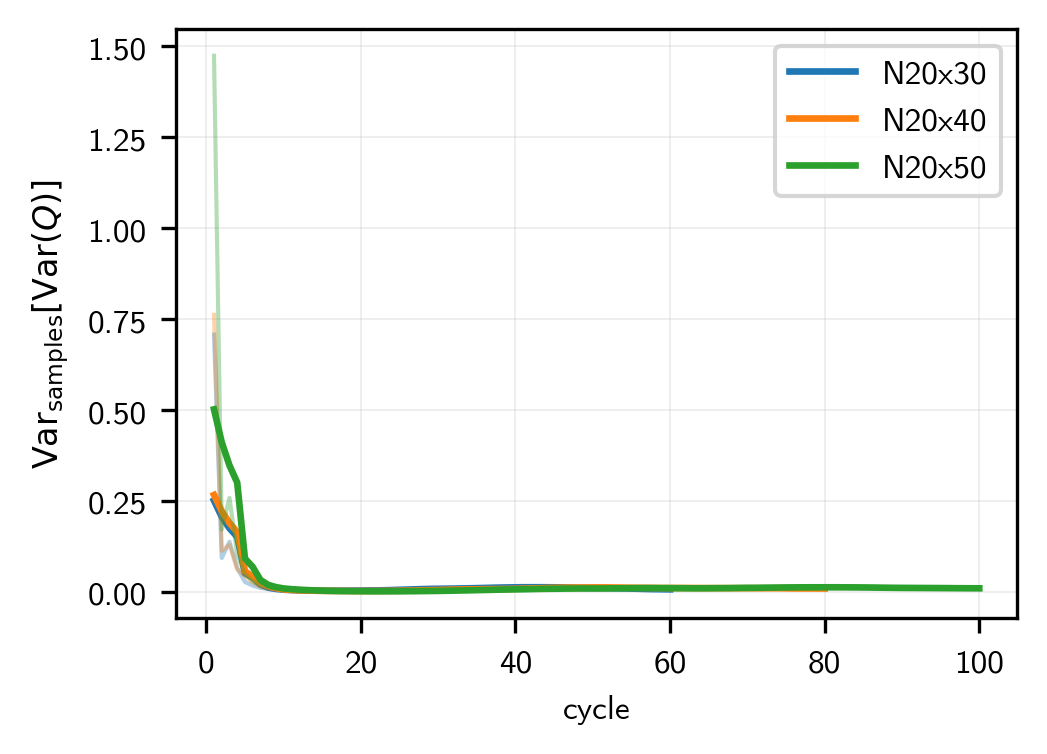

### Total-Charge-Variance Percent Variance Vs Cycle

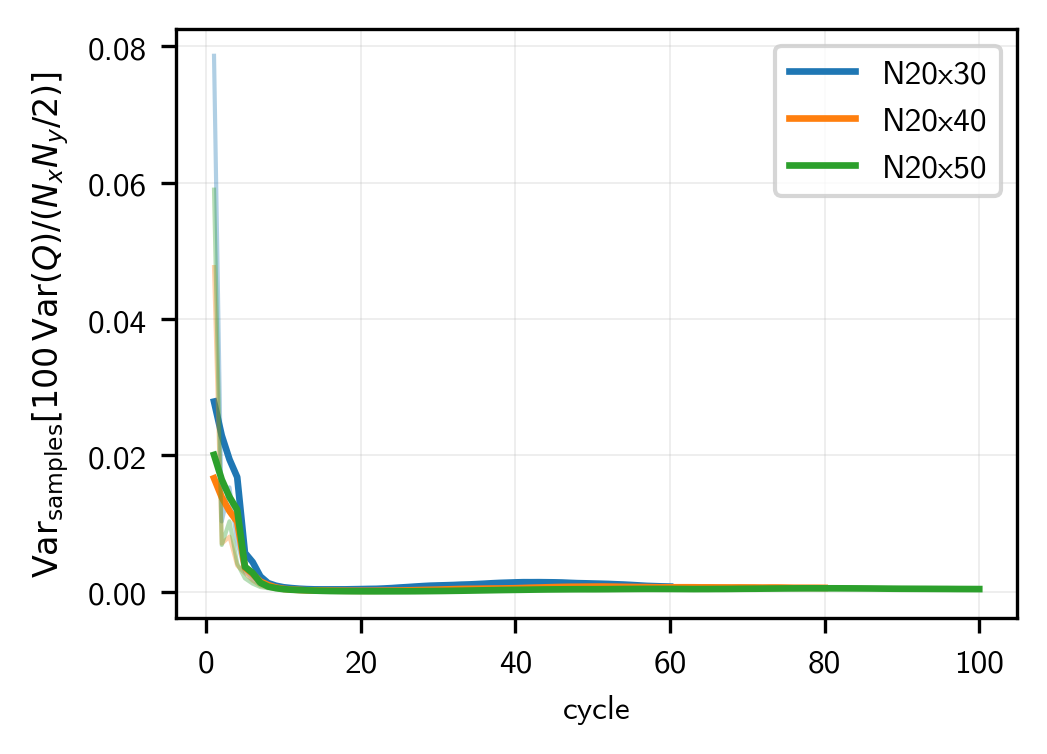

### Sample-Averaged Spatial Charge Variance Heatmap Video

### Sample-Averaged Spatial Charge Variance Final Frame

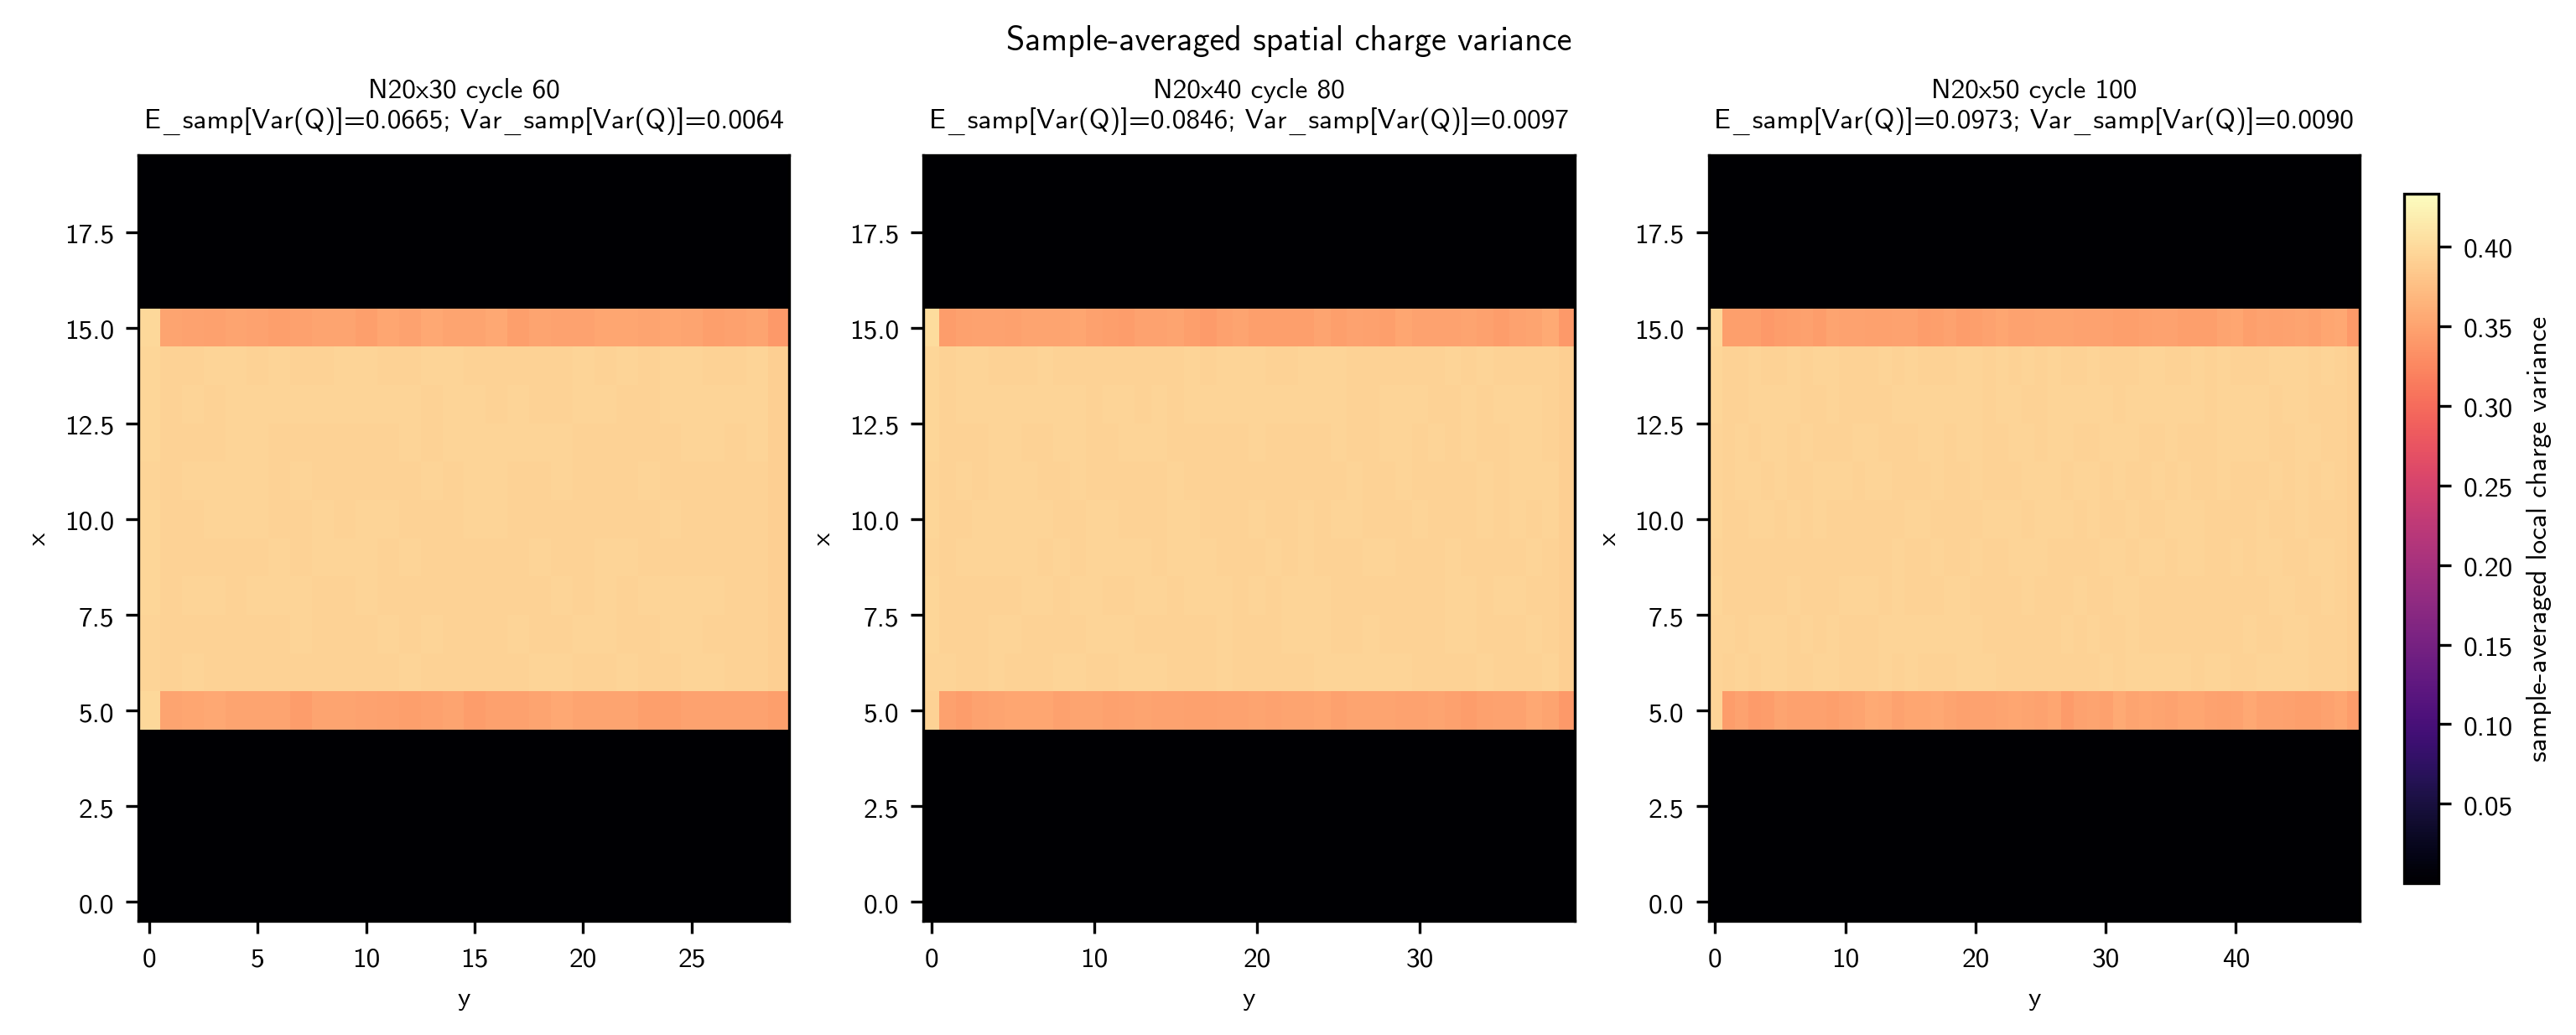

### Saved Total-Charge-Variance Sample-Statistics Table

,config_id,Nx,Ny,protocol,cycle_label,sample_count,total_charge_variance_raw_sample_mean,total_charge_variance_raw_sample_variance,total_charge_variance_raw_sample_stdev,total_charge_variance_percent_sample_mean,total_charge_variance_percent_sample_variance,total_charge_variance_percent_sample_stdev
0,N20x30_perfect_correction,20,30,perfect_correction,1,100,31.060234,0.707509,0.841135,10.353411,0.078612,0.280378
1,N20x30_perfect_correction,20,30,perfect_correction,2,100,8.115137,0.092748,0.304545,2.705046,0.010305,0.101515
2,N20x30_perfect_correction,20,30,perfect_correction,3,100,4.351212,0.137721,0.371108,1.450404,0.015302,0.123703
3,N20x30_perfect_correction,20,30,perfect_correction,4,100,2.909342,0.065830,0.256573,0.969781,0.007314,0.085524
4,N20x30_perfect_correction,20,30,perfect_correction,5,100,2.131638,0.026990,0.164286,0.710546,0.002999,0.054762
5,N20x30_perfect_correction,20,30,perfect_correction,6,100,1.703273,0.017078,0.130682,0.567758,0.001898,0.043561
6,N20x30_perfect_correction,20,30,perfect_correction,7,100,1.406906,0.010544,0.102682,0.468969,0.001172,0.034227
7,N20x30_perfect_correction,20,30,perfect_correction,8,100,1.212315,0.008391,0.091602,0.404105,0.000932,0.030534
8,N20x30_perfect_correction,20,30,perfect_correction,9,100,1.057132,0.006777,0.082321,0.352377,0.000753,0.027440
9,N20x30_perfect_correction,20,30,perfect_correction,10,100,0.931725,0.005343,0.073093,0.310575,0.000594,0.024364


In [8]:
if RUN_CENTERED_CHARGE_HISTOGRAM_VIDEO:
    video_artifacts = make_centered_total_charge_histogram_video(
        centered_charge_records,
        output_root=figure_root,
    )
    display_video_if_exists("Centered Total-Charge Histogram Comparison Video", video_artifacts.get("video_path"))
    display_image_if_exists("Centered Total-Charge Final Frame", video_artifacts.get("final_frame_path"))
else:
    video_artifacts = {}

if RUN_CENTERED_CHARGE_VARIANCE_FIGURES:
    variance_artifacts = make_centered_total_charge_variance_figures(
        centered_charge_records,
        output_root=figure_root,
    )
    for title, key in [
        ("Centered-Charge Raw Mean Vs Cycle", "raw_mean_path"),
        ("Centered-Charge Raw Mean With Sample Stdev Vs Cycle", "raw_mean_std_path"),
        ("Centered-Charge Percent Mean Vs Cycle", "percent_mean_path"),
        ("Centered-Charge Percent Mean With Sample Stdev Vs Cycle", "percent_mean_std_path"),
        ("Centered-Charge Raw Variance Vs Cycle", "raw_variance_path"),
        ("Centered-Charge Percent Variance Vs Cycle", "percent_variance_path"),
    ]:
        display_image_if_exists(title, variance_artifacts.get(key))
else:
    variance_artifacts = {}

if RUN_REAL_SPACE_CHERN_FIGURE:
    chern_artifacts = make_real_space_chern_loglog_figure(
        real_space_chern_records,
        output_root=figure_root,
    )
    display_image_if_exists(
        "Sample-Averaged Real-Space Chern Number Vs Cycle Log-Log",
        chern_artifacts.get("chern_loglog_path"),
    )
else:
    chern_artifacts = {}

if RUN_TOTAL_ENTROPY_FIGURE:
    entropy_artifacts = make_total_entropy_loglog_figure(
        total_entropy_records,
        output_root=figure_root,
    )
    display_image_if_exists(
        "Sample-Averaged Total Entropy Vs Cycle Log-Log",
        entropy_artifacts.get("entropy_loglog_path"),
    )
    display_image_if_exists(
        "Sample-Averaged Total Entropy With Sample Stdev Vs Cycle Log-Log",
        entropy_artifacts.get("entropy_loglog_std_path"),
    )
else:
    entropy_artifacts = {}

if RUN_EXPECTED_CHARGE_HEATMAP_VIDEO:
    expected_charge_video_artifacts = make_sample_averaged_expected_charge_video(
        centered_charge_records,
        output_root=figure_root,
    )
    display_video_if_exists(
        "Sample-Averaged Expected Charge Heatmap Video",
        expected_charge_video_artifacts.get("video_path"),
    )
    display_image_if_exists(
        "Sample-Averaged Expected Charge Final Frame",
        expected_charge_video_artifacts.get("final_frame_path"),
    )
else:
    expected_charge_video_artifacts = {}

if WRITE_MANIFESTS:
    analysis_paths = write_centered_total_charge_analysis_manifest(
        bundle_root=BUNDLE_ROOT,
        campaign_id=campaign_id,
        records=centered_charge_records,
        stats_df=centered_charge_stats_df,
        video_artifacts=video_artifacts,
        variance_artifacts=variance_artifacts,
        entropy_artifacts=entropy_artifacts,
        chern_artifacts=chern_artifacts,
        expected_charge_video_artifacts=expected_charge_video_artifacts,
    )
    if analysis_paths.get("stats_table_path") and Path(analysis_paths["stats_table_path"]).exists():
        display(Markdown("### Saved Centered-Charge Sample-Statistics Table"))
        display(pd.read_csv(analysis_paths["stats_table_path"]).head(12))
else:
    analysis_paths = {}

if RUN_TOTAL_CHARGE_VARIANCE_HISTOGRAM_VIDEO:
    total_charge_variance_video_artifacts = make_total_charge_variance_histogram_video(
        total_charge_variance_records,
        output_root=variance_figure_root,
    )
    display_video_if_exists(
        "Total-Charge-Variance Histogram Comparison Video",
        total_charge_variance_video_artifacts.get("video_path"),
    )
    display_image_if_exists(
        "Total-Charge-Variance Final Frame",
        total_charge_variance_video_artifacts.get("final_frame_path"),
    )
else:
    total_charge_variance_video_artifacts = {}

if RUN_TOTAL_CHARGE_VARIANCE_SUMMARY_FIGURES:
    total_charge_variance_summary_artifacts = make_total_charge_variance_summary_figures(
        total_charge_variance_records,
        output_root=variance_figure_root,
    )
    for title, key in [
        ("Total-Charge-Variance Raw Mean Vs Cycle", "raw_mean_path"),
        ("Total-Charge-Variance Raw Mean With Sample Stdev Vs Cycle", "raw_mean_std_path"),
        ("Total-Charge-Variance Percent Mean Vs Cycle", "percent_mean_path"),
        ("Total-Charge-Variance Percent Mean With Sample Stdev Vs Cycle", "percent_mean_std_path"),
        ("Total-Charge-Variance Raw Variance Vs Cycle", "raw_variance_path"),
        ("Total-Charge-Variance Percent Variance Vs Cycle", "percent_variance_path"),
    ]:
        display_image_if_exists(title, total_charge_variance_summary_artifacts.get(key))
else:
    total_charge_variance_summary_artifacts = {}

if RUN_SPATIAL_CHARGE_VARIANCE_HEATMAP_VIDEO:
    spatial_charge_variance_video_artifacts = make_sample_averaged_spatial_charge_variance_video(
        total_charge_variance_records,
        output_root=variance_figure_root,
    )
    display_video_if_exists(
        "Sample-Averaged Spatial Charge Variance Heatmap Video",
        spatial_charge_variance_video_artifacts.get("video_path"),
    )
    display_image_if_exists(
        "Sample-Averaged Spatial Charge Variance Final Frame",
        spatial_charge_variance_video_artifacts.get("final_frame_path"),
    )
else:
    spatial_charge_variance_video_artifacts = {}

if WRITE_MANIFESTS:
    total_charge_variance_analysis_paths = write_total_charge_variance_analysis_manifest(
        bundle_root=BUNDLE_ROOT,
        campaign_id=campaign_id,
        records=total_charge_variance_records,
        stats_df=total_charge_variance_stats_df,
        video_artifacts=total_charge_variance_video_artifacts,
        summary_artifacts=total_charge_variance_summary_artifacts,
        spatial_variance_video_artifacts=spatial_charge_variance_video_artifacts,
    )
    if (
        total_charge_variance_analysis_paths.get("stats_table_path")
        and Path(total_charge_variance_analysis_paths["stats_table_path"]).exists()
    ):
        display(Markdown("### Saved Total-Charge-Variance Sample-Statistics Table"))
        display(pd.read_csv(total_charge_variance_analysis_paths["stats_table_path"]).head(12))
else:
    total_charge_variance_analysis_paths = {}


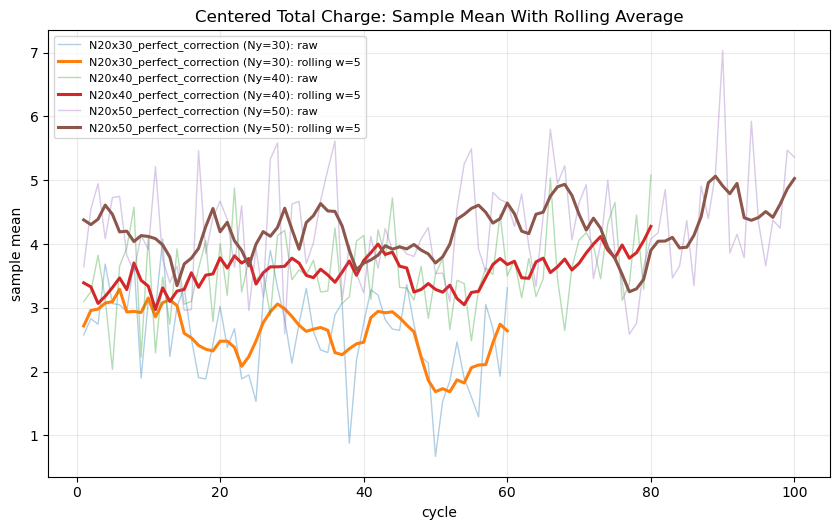

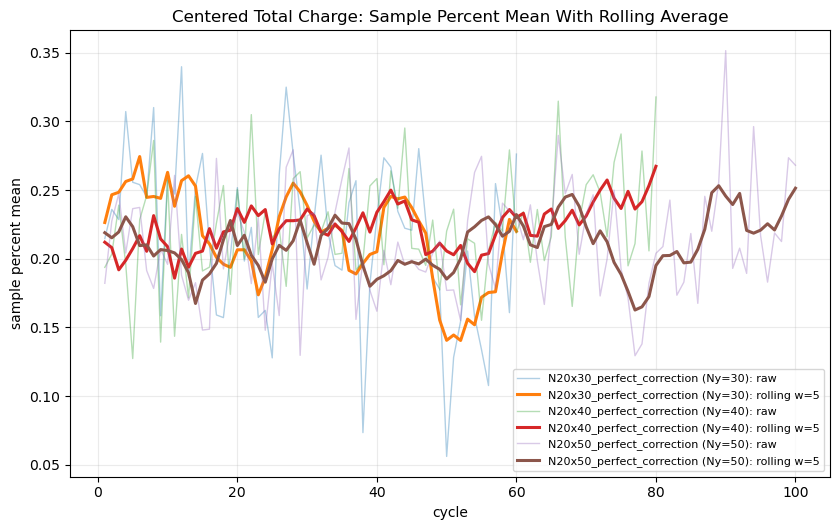

[rolling raw mean overlay] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_total_charge_histogram_video_cpu/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/rolling_averages/centered_charge_sample_mean_with_rolling_average.png
[rolling percent mean overlay] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_total_charge_histogram_video_cpu/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/rolling_averages/centered_charge_sample_percent_mean_with_rolling_average.png


In [9]:
# --------------------------------------------------------------------
# Rolling-average overlays for sample mean and sample percent mean
# --------------------------------------------------------------------
import matplotlib.pyplot as plt


def _find_column(df, candidates, *, required=True, label="column"):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(
            f"Could not find {label}. Tried {candidates}. Available columns: {list(df.columns)}"
        )
    return None


def _ensure_cycle_column(df):
    cycle_col = _find_column(df, ["cycle", "cycles", "cycle_index", "cycle_label", "t"], label="cycle column")
    return cycle_col


def _ensure_config_column(df):
    return _find_column(df, ["config_id", "config", "run", "run_id"], label="config column")


def _ensure_ny_column(df):
    return _find_column(df, ["Ny", "ny", "L", "Ly"], label="Ny column")


def add_grouped_rolling_average(
    df,
    value_col,
    *,
    group_cols=None,
    cycle_col=None,
    window=ROLLING_AVERAGE_WINDOW,
    min_periods=ROLLING_AVERAGE_MIN_PERIODS,
    center=ROLLING_AVERAGE_CENTER,
):
    """Return a sorted copy of df with an added rolling-average column."""
    if cycle_col is None:
        cycle_col = _ensure_cycle_column(df)
    if group_cols is None:
        group_cols = [_ensure_config_column(df)]

    out = df.copy().sort_values(group_cols + [cycle_col])
    rolled_col = f"{value_col}_rolling_w{window}"
    out[rolled_col] = (
        out.groupby(group_cols, group_keys=False)[value_col]
        .rolling(window=window, min_periods=min_periods, center=center)
        .mean()
        .reset_index(level=list(range(len(group_cols))), drop=True)
    )
    return out, rolled_col


def make_rolling_overlay_figure(
    df,
    value_col,
    *,
    title,
    ylabel,
    output_root,
    filename,
    window=ROLLING_AVERAGE_WINDOW,
):
    cycle_col = _ensure_cycle_column(df)
    config_col = _ensure_config_column(df)
    ny_col = _ensure_ny_column(df)

    plot_df, rolled_col = add_grouped_rolling_average(
        df,
        value_col,
        group_cols=[config_col],
        cycle_col=cycle_col,
        window=window,
    )

    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)
    output_path = output_root / filename

    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    for config_id, group in plot_df.groupby(config_col, sort=False):
        group = group.sort_values(cycle_col)
        ny_value = group[ny_col].iloc[0] if ny_col in group.columns else "?"
        label = f"{config_id} (Ny={ny_value})"
        ax.plot(group[cycle_col], group[value_col], alpha=0.35, linewidth=1.0, label=f"{label}: raw")
        ax.plot(group[cycle_col], group[rolled_col], linewidth=2.2, label=f"{label}: rolling w={window}")

    ax.set_xlabel("cycle")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.show()
    plt.close(fig)

    return output_path, plot_df, rolled_col


centered_cycle_col = _ensure_cycle_column(centered_charge_stats_df)
centered_mean_col = _find_column(
    centered_charge_stats_df,
    ["centered_total_charge_raw_sample_mean", "raw_mean", "q_raw_mean", "sample_raw_mean", "mean_raw", "mean"],
    label="centered-charge sample raw mean column",
)
centered_percent_mean_col = _find_column(
    centered_charge_stats_df,
    ["centered_total_charge_percent_sample_mean", "percent_mean", "pct_mean", "q_pct_mean", "sample_percent_mean", "sample_pct_mean"],
    label="centered-charge sample percent mean column",
)
centered_percent_variance_col = _find_column(
    centered_charge_stats_df,
    ["centered_total_charge_percent_sample_variance", "percent_variance", "pct_variance", "q_pct_variance", "sample_percent_variance", "sample_pct_variance"],
    label="centered-charge sample percent variance column",
)

if RUN_ROLLING_AVERAGE_OVERLAY_FIGURES:
    rolling_output_root = figure_root / "rolling_averages"

    raw_mean_path, centered_charge_rolling_df, centered_raw_mean_rolled_col = make_rolling_overlay_figure(
        centered_charge_stats_df,
        centered_mean_col,
        title="Centered Total Charge: Sample Mean With Rolling Average",
        ylabel="sample mean",
        output_root=rolling_output_root,
        filename="centered_charge_sample_mean_with_rolling_average.png",
    )

    pct_mean_path, centered_charge_rolling_df, centered_percent_mean_rolled_col = make_rolling_overlay_figure(
        centered_charge_rolling_df,
        centered_percent_mean_col,
        title="Centered Total Charge: Sample Percent Mean With Rolling Average",
        ylabel="sample percent mean",
        output_root=rolling_output_root,
        filename="centered_charge_sample_percent_mean_with_rolling_average.png",
    )

    # Also add the percent-variance rolling column now, so the Ny-scaling cell can use it.
    centered_charge_rolling_df, centered_percent_variance_rolled_col = add_grouped_rolling_average(
        centered_charge_rolling_df,
        centered_percent_variance_col,
        group_cols=[_ensure_config_column(centered_charge_rolling_df)],
        cycle_col=_ensure_cycle_column(centered_charge_rolling_df),
    )

    print(f"[rolling raw mean overlay] {raw_mean_path}")
    print(f"[rolling percent mean overlay] {pct_mean_path}")
else:
    centered_charge_rolling_df, centered_percent_mean_rolled_col = add_grouped_rolling_average(
        centered_charge_stats_df,
        centered_percent_mean_col,
        group_cols=[_ensure_config_column(centered_charge_stats_df)],
        cycle_col=centered_cycle_col,
    )
    centered_charge_rolling_df, centered_percent_variance_rolled_col = add_grouped_rolling_average(
        centered_charge_rolling_df,
        centered_percent_variance_col,
        group_cols=[_ensure_config_column(centered_charge_rolling_df)],
        cycle_col=centered_cycle_col,
    )

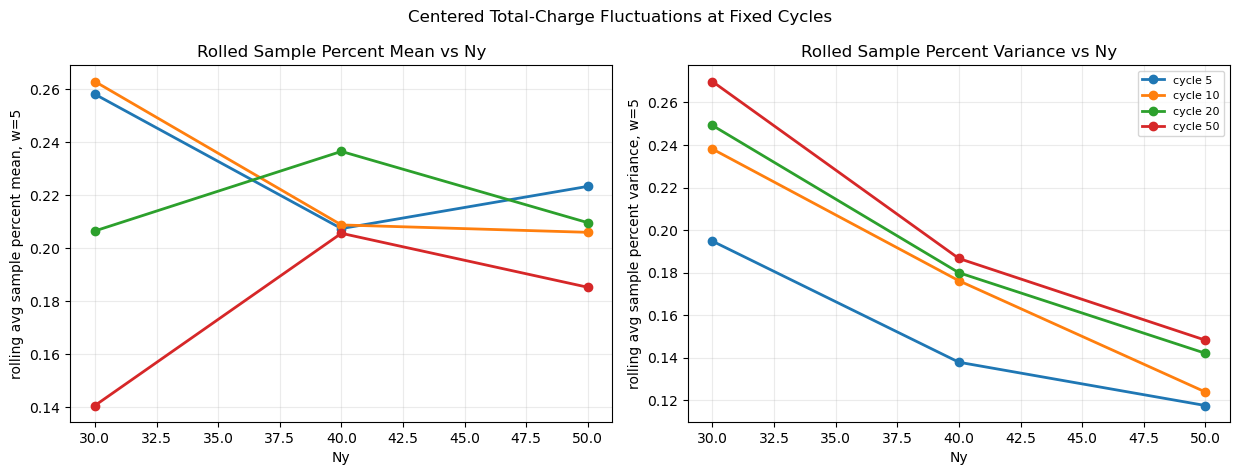

[Ny scaling figure] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_total_charge_histogram_video_cpu/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/rolling_averages/centered_charge_rolled_percent_mean_and_variance_vs_Ny.png


### Rows Used For Ny Scaling Figure

,config_id,Nx,Ny,protocol,cycle_label,sample_count,centered_total_charge_raw_sample_mean,centered_total_charge_raw_sample_variance,centered_total_charge_raw_sample_stdev,centered_total_charge_percent_sample_mean,centered_total_charge_percent_sample_variance,centered_total_charge_percent_sample_stdev,centered_total_charge_raw_sample_mean_rolling_w5,centered_total_charge_percent_sample_mean_rolling_w5,centered_total_charge_percent_sample_variance_rolling_w5,target_cycle,selected_cycle,cycle_offset
4,N20x30_perfect_correction,20,30,perfect_correction,5,100,3.068372,21.539275,4.641042,0.255698,0.149578,0.386754,3.097326,0.258111,0.194770,5,5,0
64,N20x40_perfect_correction,20,40,perfect_correction,5,100,2.036669,30.977175,5.565714,0.127292,0.121005,0.347857,3.318134,0.207383,0.137810,5,5,0
144,N20x50_perfect_correction,20,50,perfect_correction,5,100,4.729442,51.297511,7.162228,0.236472,0.128244,0.358111,4.466549,0.223327,0.117444,5,5,0
9,N20x30_perfect_correction,20,30,perfect_correction,10,100,3.108234,32.307428,5.683962,0.259020,0.224357,0.473664,3.154957,0.262913,0.238106,10,10,0
69,N20x40_perfect_correction,20,40,perfect_correction,10,100,4.114465,43.897969,6.625554,0.257154,0.171476,0.414097,3.340136,0.208758,0.176141,10,10,0
149,N20x50_perfect_correction,20,50,perfect_correction,10,100,3.917616,57.217500,7.564225,0.195881,0.143044,0.378211,4.119342,0.205967,0.123814,10,10,0
19,N20x30_perfect_correction,20,30,perfect_correction,20,100,3.021410,34.228031,5.850473,0.251784,0.237695,0.487539,2.477910,0.206492,0.249205,20,20,0
79,N20x40_perfect_correction,20,40,perfect_correction,20,100,4.008742,43.067662,6.562596,0.250546,0.168233,0.410162,3.784449,0.236528,0.179921,20,20,0
159,N20x50_perfect_correction,20,50,perfect_correction,20,100,4.673021,54.203025,7.362270,0.233651,0.135508,0.368114,4.192148,0.209607,0.142016,20,20,0
49,N20x30_perfect_correction,20,30,perfect_correction,50,100,0.671772,37.300452,6.107410,0.055981,0.259031,0.508951,1.686726,0.140560,0.269853,50,50,0


In [10]:
# --------------------------------------------------------------------
# Ny scaling at fixed cycles using rolled sample percent mean / variance
# --------------------------------------------------------------------

def select_nearest_cycle_rows(
    df,
    *,
    target_cycles=NY_SCALING_TARGET_CYCLES,
    value_cols,
):
    cycle_col = _ensure_cycle_column(df)
    config_col = _ensure_config_column(df)
    ny_col = _ensure_ny_column(df)

    rows = []
    for target_cycle in target_cycles:
        for config_id, group in df.groupby(config_col, sort=False):
            group = group.dropna(subset=list(value_cols)).copy()
            if group.empty:
                continue
            idx = (group[cycle_col] - target_cycle).abs().idxmin()
            row = group.loc[idx].copy()
            row["target_cycle"] = target_cycle
            row["selected_cycle"] = row[cycle_col]
            row["cycle_offset"] = row[cycle_col] - target_cycle
            rows.append(row)

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["target_cycle", ny_col, config_col])
    return out


def make_ny_scaling_figure(
    df,
    *,
    percent_mean_rolled_col,
    percent_variance_rolled_col,
    output_root,
    filename="centered_charge_rolled_percent_mean_and_variance_vs_Ny.png",
):
    config_col = _ensure_config_column(df)
    ny_col = _ensure_ny_column(df)

    scaling_df = select_nearest_cycle_rows(
        df,
        target_cycles=NY_SCALING_TARGET_CYCLES,
        value_cols=[percent_mean_rolled_col, percent_variance_rolled_col],
    )

    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)
    output_path = output_root / filename

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)

    for target_cycle, group in scaling_df.groupby("target_cycle", sort=True):
        group = group.sort_values(ny_col)
        axes[0].plot(
            group[ny_col],
            group[percent_mean_rolled_col],
            marker="o",
            linewidth=2.0,
            label=f"cycle {target_cycle}",
        )
        axes[1].plot(
            group[ny_col],
            group[percent_variance_rolled_col],
            marker="o",
            linewidth=2.0,
            label=f"cycle {target_cycle}",
        )

    axes[0].set_title("Rolled Sample Percent Mean vs Ny")
    axes[0].set_xlabel("Ny")
    axes[0].set_ylabel(f"rolling avg sample percent mean, w={ROLLING_AVERAGE_WINDOW}")
    axes[0].grid(True, alpha=0.25)

    axes[1].set_title("Rolled Sample Percent Variance vs Ny")
    axes[1].set_xlabel("Ny")
    axes[1].set_ylabel(f"rolling avg sample percent variance, w={ROLLING_AVERAGE_WINDOW}")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(fontsize=8)

    fig.suptitle("Centered Total-Charge Fluctuations at Fixed Cycles")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.show()
    plt.close(fig)

    return output_path, scaling_df


if RUN_NY_ROLLING_AVERAGE_SCALING_FIGURE:
    ny_scaling_path, ny_scaling_df = make_ny_scaling_figure(
        centered_charge_rolling_df,
        percent_mean_rolled_col=centered_percent_mean_rolled_col,
        percent_variance_rolled_col=centered_percent_variance_rolled_col,
        output_root=figure_root / "rolling_averages",
    )
    print(f"[Ny scaling figure] {ny_scaling_path}")
    display(Markdown("### Rows Used For Ny Scaling Figure"))
    display(ny_scaling_df)
else:
    ny_scaling_path = None
    ny_scaling_df = pd.DataFrame()
    print("[Ny scaling skipped] Set RUN_NY_ROLLING_AVERAGE_SCALING_FIGURE = True to generate it.")


In [11]:
# display helpers defined in setup cell above

## 6. Post-Selection Characterization

Each post-selection run has a single sample trajectory (`samples_actual = 1`), so sample statistics are not applicable. This section:
- Plots the single-trajectory time series of entropy, Chern number, and total charge variance directly (no averaging, no stdev bands)
- Generates static final-cycle spatial heatmaps of charge density and charge variance
- Overlays the postselect trajectory against the perfect-correction sample average for direct comparison

In [12]:
# --------------------------------------------------------------------
# Post-selection analysis toggles
# --------------------------------------------------------------------
RUN_POSTSELECT_CHARGE_VIDEO = True        # spatial charge density video (3 frames/cycle)
RUN_POSTSELECT_ENTROPY_FIGURE = True
RUN_POSTSELECT_CHERN_FIGURE = True
RUN_POSTSELECT_VARIANCE_FIGURE = True
RUN_POSTSELECT_SPATIAL_FIGURES = True     # static final-cycle heatmaps
RUN_PROTOCOL_COMPARISON_FIGURES = True

In [13]:
# Reload module to pick up new protocol parameter and make_protocol_comparison_figures.
pthv = importlib.reload(pthv)

make_protocol_comparison_figures = pthv.make_protocol_comparison_figures
POSTSELECT_PROTOCOL = pthv.POSTSELECT_PROTOCOL

# Prepare postselect records.
post_centered_charge_records = prepare_centered_total_charge_histogram_records(
    payload=payload, protocol=POSTSELECT_PROTOCOL
)
post_entropy_records = prepare_total_entropy_records(
    payload=payload, protocol=POSTSELECT_PROTOCOL
)
post_chern_records = prepare_real_space_chern_records(
    payload=payload, protocol=POSTSELECT_PROTOCOL
)
post_variance_records = prepare_total_charge_variance_histogram_records(
    payload=payload, protocol=POSTSELECT_PROTOCOL
)

post_centered_charge_records = filter_records(post_centered_charge_records, SELECTED_CONFIG_IDS)
post_entropy_records = filter_records(post_entropy_records, SELECTED_CONFIG_IDS)
post_chern_records = filter_records(post_chern_records, SELECTED_CONFIG_IDS)
post_variance_records = filter_records(post_variance_records, SELECTED_CONFIG_IDS)

postselect_figure_root = (
    BUNDLE_ROOT / "analysis_outputs" / "purification_postselect_characterization" / campaign_id / "figures"
)
comparison_figure_root = (
    BUNDLE_ROOT / "analysis_outputs" / "purification_protocol_comparison" / campaign_id / "figures"
)

display(Markdown("### Postselect Record Overview"))
display(
    pd.DataFrame(
        [
            {
                "config_id": r["config_id"],
                "Nx": r["Nx"],
                "Ny": r["Ny"],
                "samples_actual": r["samples_actual"],
                "cycles": r["cycles"],
            }
            for r in post_centered_charge_records
        ]
    )
)

### Postselect Record Overview

,config_id,Nx,Ny,samples_actual,cycles
0,N20x30_postselect,20,30,1,60
1,N20x40_postselect,20,40,1,80
2,N20x50_postselect,20,50,1,100


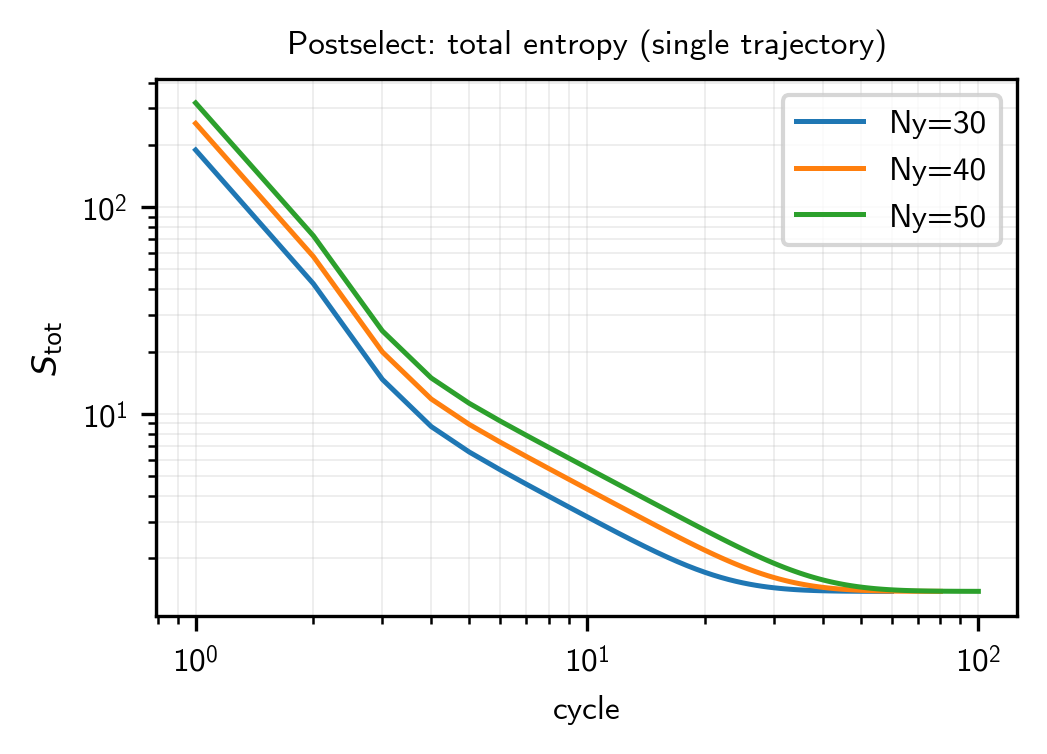

[postselect entropy] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_postselect_characterization/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/postselect_total_entropy_vs_cycle_loglog.png


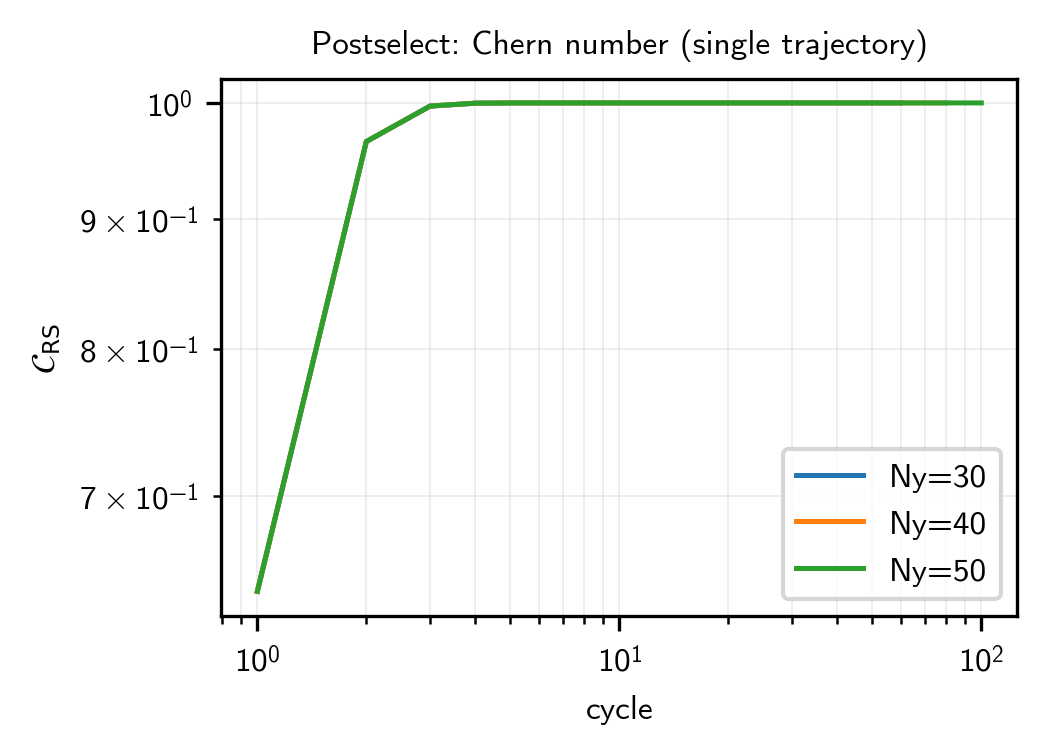

[postselect Chern] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_postselect_characterization/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/postselect_chern_vs_cycle_loglog.png


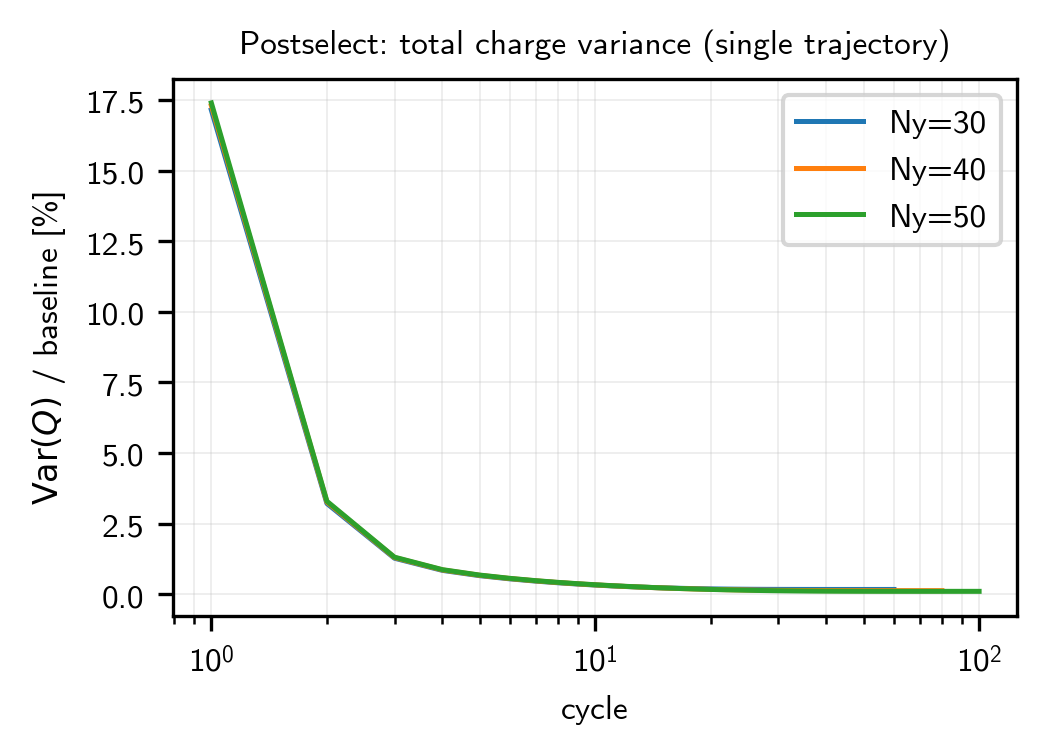

[postselect variance] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_postselect_characterization/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/postselect_total_charge_variance_pct_vs_cycle.png


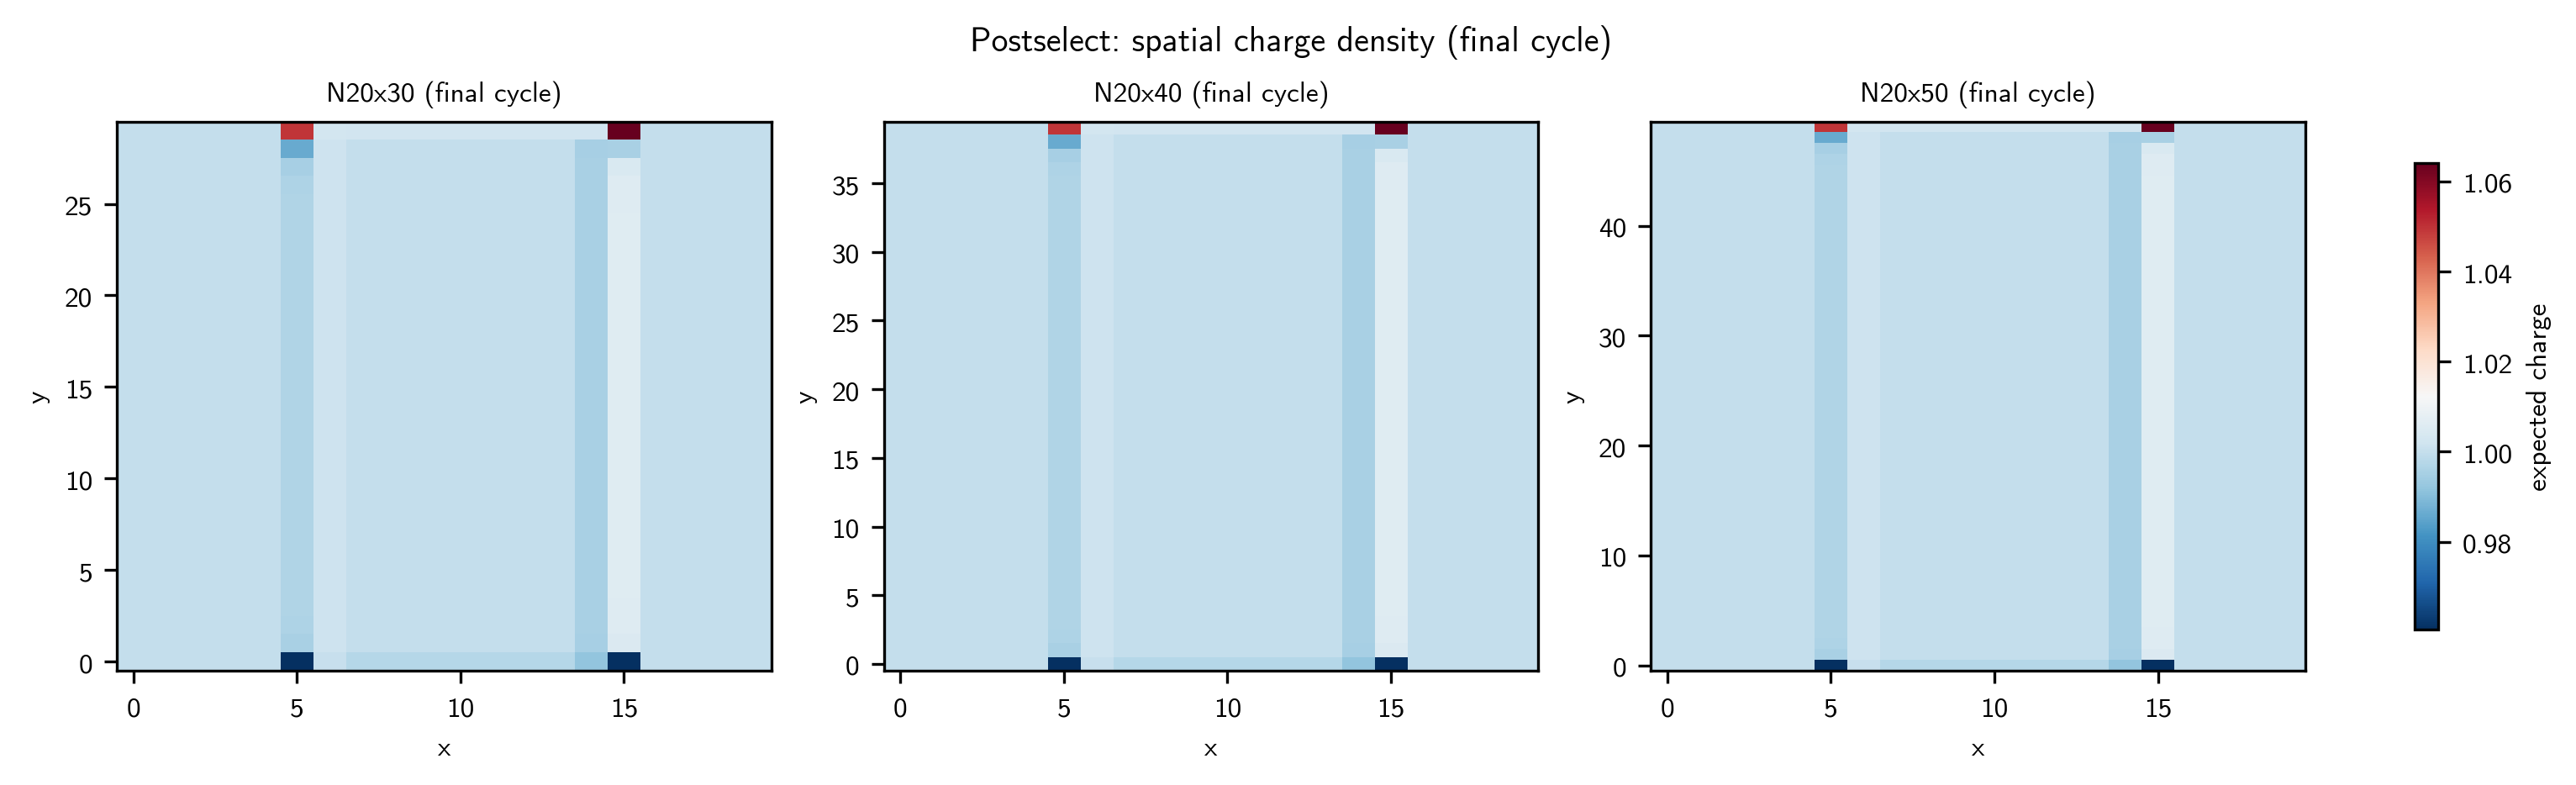

[postselect charge heatmap] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_postselect_characterization/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/postselect_spatial_charge_mean_final_cycle.png


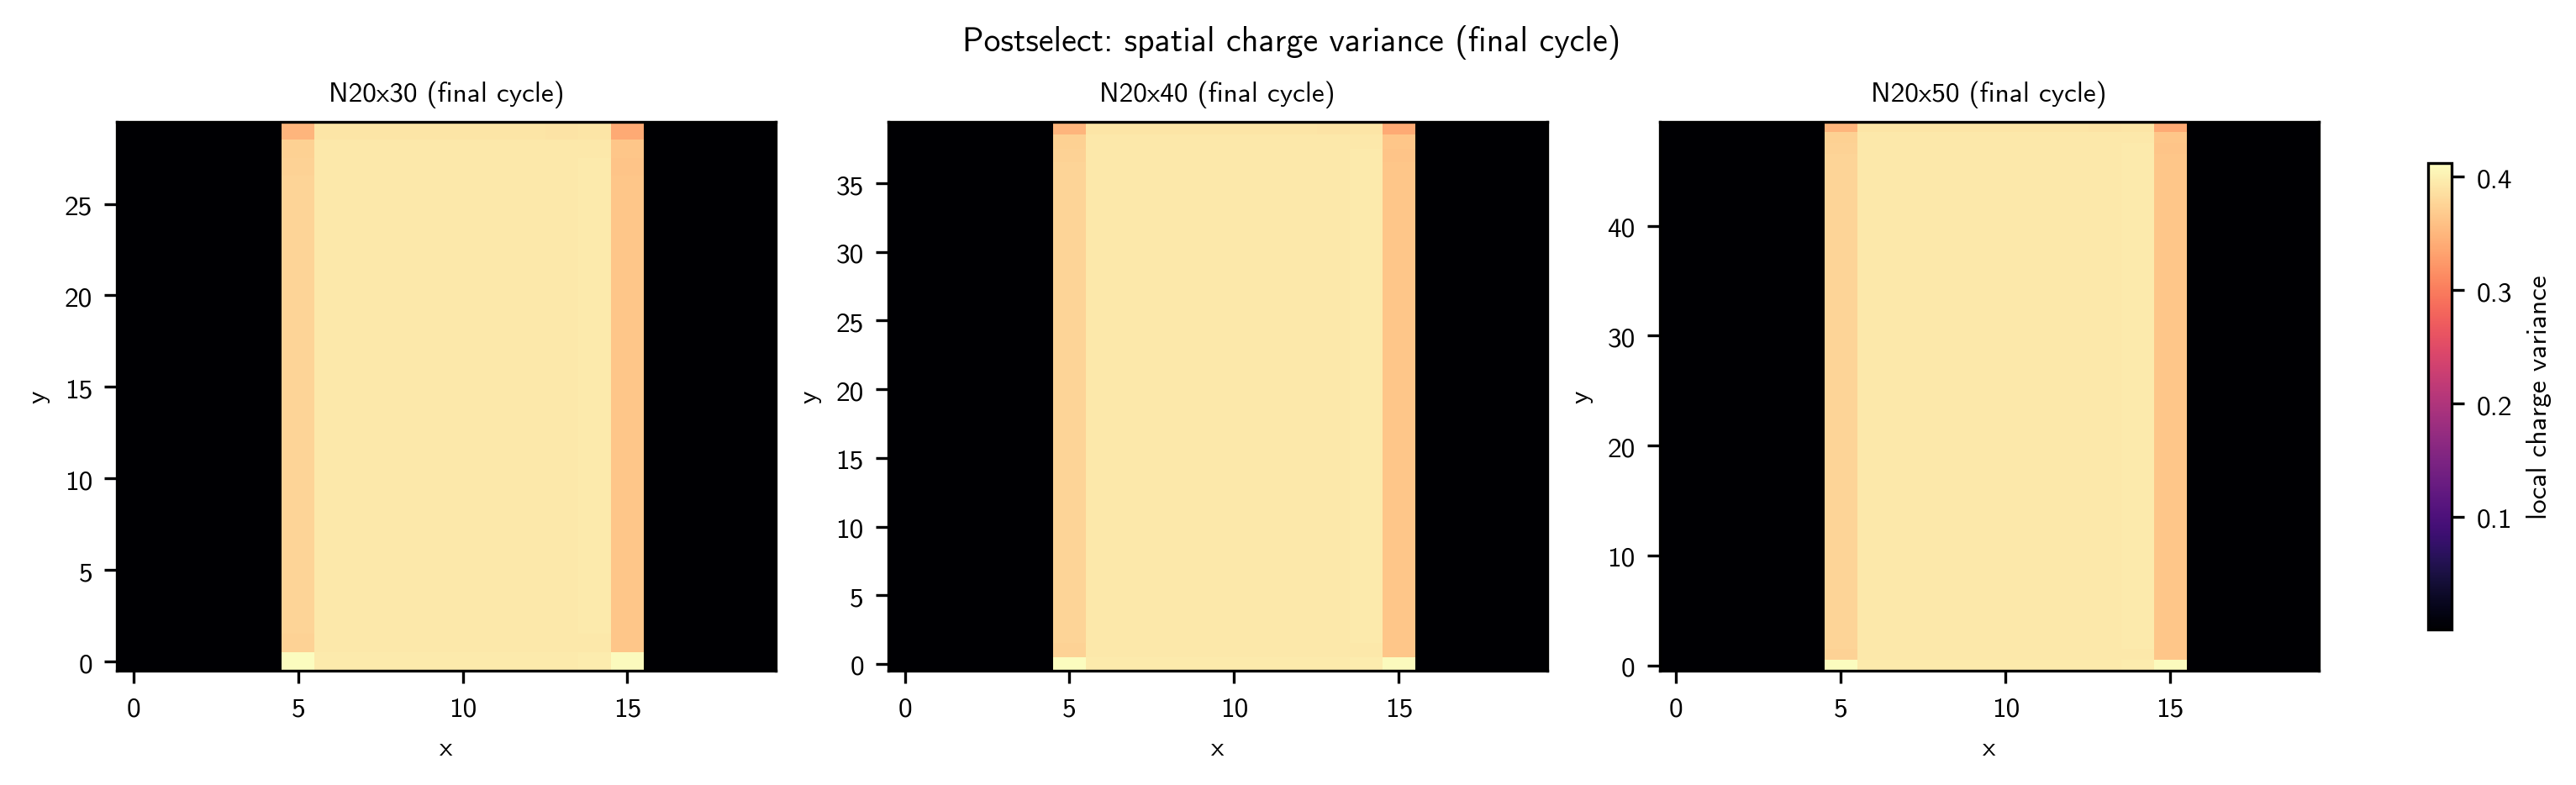

[postselect variance heatmap] /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_postselect_characterization/N20_multi_geometry_nsh1_dwtrunc1_init-maxmix_S100_cycles-2Ny/figures/postselect_spatial_charge_variance_final_cycle.png


### Protocol Comparison: Total Entropy

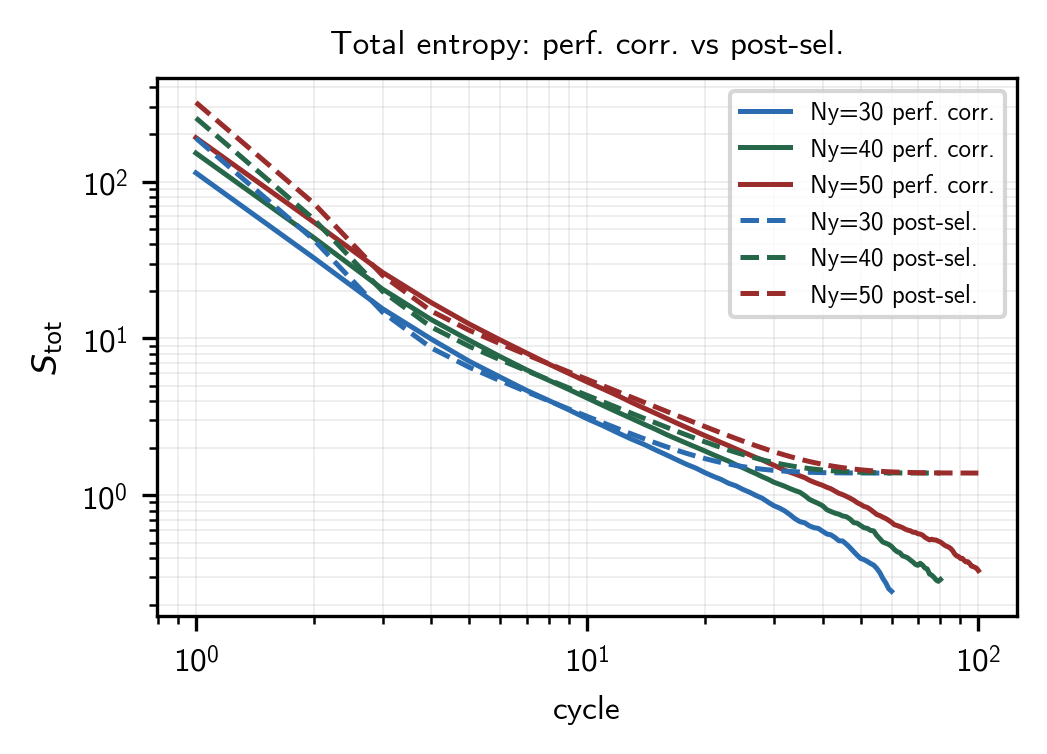

### Protocol Comparison: Chern Number

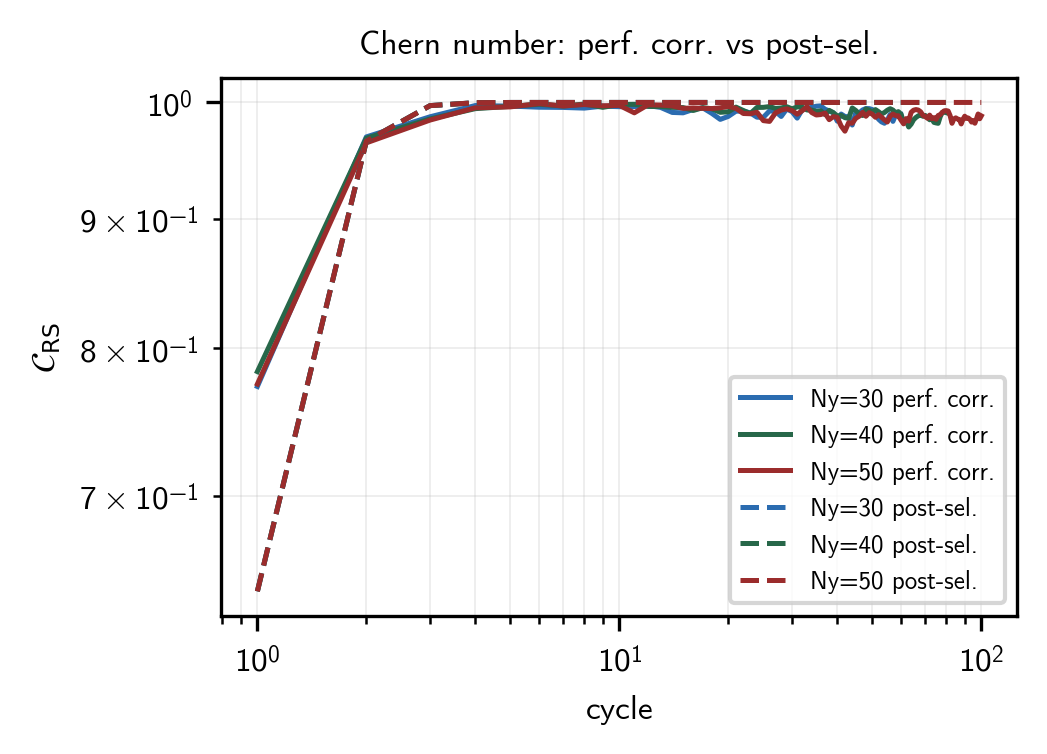

### Protocol Comparison: Total Charge Variance

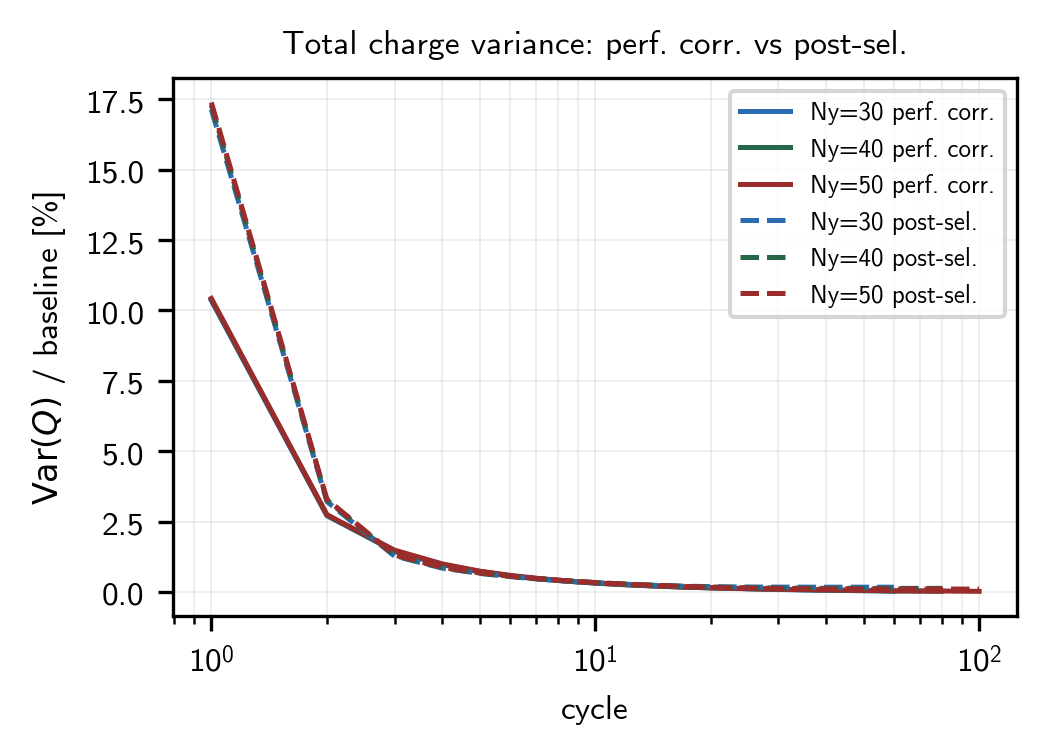

In [14]:
postselect_figure_root.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------
# Scalar time-series figures (single trajectory — squeeze sample axis)
# -----------------------------------------------------------------------

def _make_postselect_scalar_figure(
    records,
    *,
    data_fn,
    ylabel,
    title,
    filename,
    loglog=True,
):
    output_path = postselect_figure_root / filename
    with plt.rc_context(pthv._style_context()):
        fig, ax = plt.subplots(figsize=pthv.PLOT_FIGSIZE, constrained_layout=True)
        for record in records:
            values = data_fn(record)          # shape (cycles,) — already squeezed
            cycles = np.arange(1, len(values) + 1, dtype=np.float64)
            ax.plot(cycles, values, linewidth=1.2, label=f"Ny={record['Ny']}")
        if loglog:
            ax.set_xscale("log")
            ax.set_yscale("log")
        else:
            ax.set_xscale("log")
        ax.set_xlabel("cycle")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc="best")
        ax.grid(alpha=0.25, linewidth=0.4, which="both")
        fig.savefig(output_path, dpi=pthv.PNG_DPI, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    return output_path


if RUN_POSTSELECT_ENTROPY_FIGURE:
    ps_entropy_path = _make_postselect_scalar_figure(
        post_entropy_records,
        data_fn=lambda r: r["total_entropy"][0],   # single sample → shape (cycles,)
        ylabel=r"$S_{\mathrm{tot}}$",
        title="Postselect: total entropy (single trajectory)",
        filename="postselect_total_entropy_vs_cycle_loglog.png",
    )
    print(f"[postselect entropy] {ps_entropy_path}")

if RUN_POSTSELECT_CHERN_FIGURE:
    ps_chern_path = _make_postselect_scalar_figure(
        post_chern_records,
        data_fn=lambda r: r["chern_mean"],          # already a 1-d array (mean over 1 sample == itself)
        ylabel=r"$\mathcal{C}_{\mathrm{RS}}$",
        title="Postselect: Chern number (single trajectory)",
        filename="postselect_chern_vs_cycle_loglog.png",
    )
    print(f"[postselect Chern] {ps_chern_path}")

if RUN_POSTSELECT_VARIANCE_FIGURE:
    ps_variance_path = _make_postselect_scalar_figure(
        post_variance_records,
        data_fn=lambda r: r["variance_pct"][0],     # single sample → shape (cycles,)
        ylabel=r"$\mathrm{Var}(Q)$ / baseline [%]",
        title="Postselect: total charge variance (single trajectory)",
        filename="postselect_total_charge_variance_pct_vs_cycle.png",
        loglog=False,
    )
    print(f"[postselect variance] {ps_variance_path}")

# -----------------------------------------------------------------------
# Spatial heatmaps at the final cycle (static PNG, no video)
# -----------------------------------------------------------------------

def _make_postselect_final_heatmap(
    records,
    *,
    data_fn,
    suptitle,
    colorbar_label,
    cmap,
    filename,
    norm=None,
):
    output_path = postselect_figure_root / filename
    n = len(records)
    with plt.rc_context(pthv._style_context()):
        fig, axes = plt.subplots(1, n, figsize=(3.375 * n, 3.0), constrained_layout=True)
        if n == 1:
            axes = [axes]
        imgs = []
        for ax, record in zip(axes, records):
            data = data_fn(record)           # shape (Nx, Ny)
            im = ax.imshow(
                data.T,
                origin="lower",
                aspect="auto",
                cmap=cmap,
                norm=norm,
            )
            imgs.append(im)
            ax.set_title(f"N{record['Nx']}x{record['Ny']} (final cycle)")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
        fig.colorbar(imgs[-1], ax=axes, label=colorbar_label, shrink=0.85)
        fig.suptitle(suptitle)
        fig.savefig(output_path, dpi=pthv.PNG_DPI, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    return output_path


if RUN_POSTSELECT_SPATIAL_FIGURES:
    # Local charge mean at final cycle: shape is (1, cycles, Nx, Ny) → squeeze sample, take last cycle
    ps_charge_heatmap_path = _make_postselect_final_heatmap(
        post_centered_charge_records,
        data_fn=lambda r: r["local_charge_cell_mean_avg"][-1],   # avg over 1 sample → (cycles, Nx, Ny); final cycle
        suptitle="Postselect: spatial charge density (final cycle)",
        colorbar_label="expected charge",
        cmap="RdBu_r",
        filename="postselect_spatial_charge_mean_final_cycle.png",
    )
    print(f"[postselect charge heatmap] {ps_charge_heatmap_path}")

    ps_variance_heatmap_path = _make_postselect_final_heatmap(
        post_variance_records,
        data_fn=lambda r: r["local_charge_cell_variance_avg"][-1],
        suptitle="Postselect: spatial charge variance (final cycle)",
        colorbar_label="local charge variance",
        cmap="magma",
        filename="postselect_spatial_charge_variance_final_cycle.png",
    )
    print(f"[postselect variance heatmap] {ps_variance_heatmap_path}")

# -----------------------------------------------------------------------
# Protocol comparison figures (postselect trajectory vs perfect-correction sample average)
# -----------------------------------------------------------------------

if RUN_PROTOCOL_COMPARISON_FIGURES:
    comparison_artifacts = make_protocol_comparison_figures(
        perf_entropy_records=total_entropy_records,
        post_entropy_records=post_entropy_records,
        perf_chern_records=real_space_chern_records,
        post_chern_records=post_chern_records,
        perf_variance_records=total_charge_variance_records,
        post_variance_records=post_variance_records,
        output_root=comparison_figure_root,
    )
    display_image_if_exists("Protocol Comparison: Total Entropy", comparison_artifacts.get("entropy_comparison_path"))
    display_image_if_exists("Protocol Comparison: Chern Number", comparison_artifacts.get("chern_comparison_path"))
    display_image_if_exists("Protocol Comparison: Total Charge Variance", comparison_artifacts.get("variance_comparison_path"))
else:
    comparison_artifacts = {}

### Postselect: Spatial Charge Density Video

### Postselect: Spatial Charge Density — Final Frame

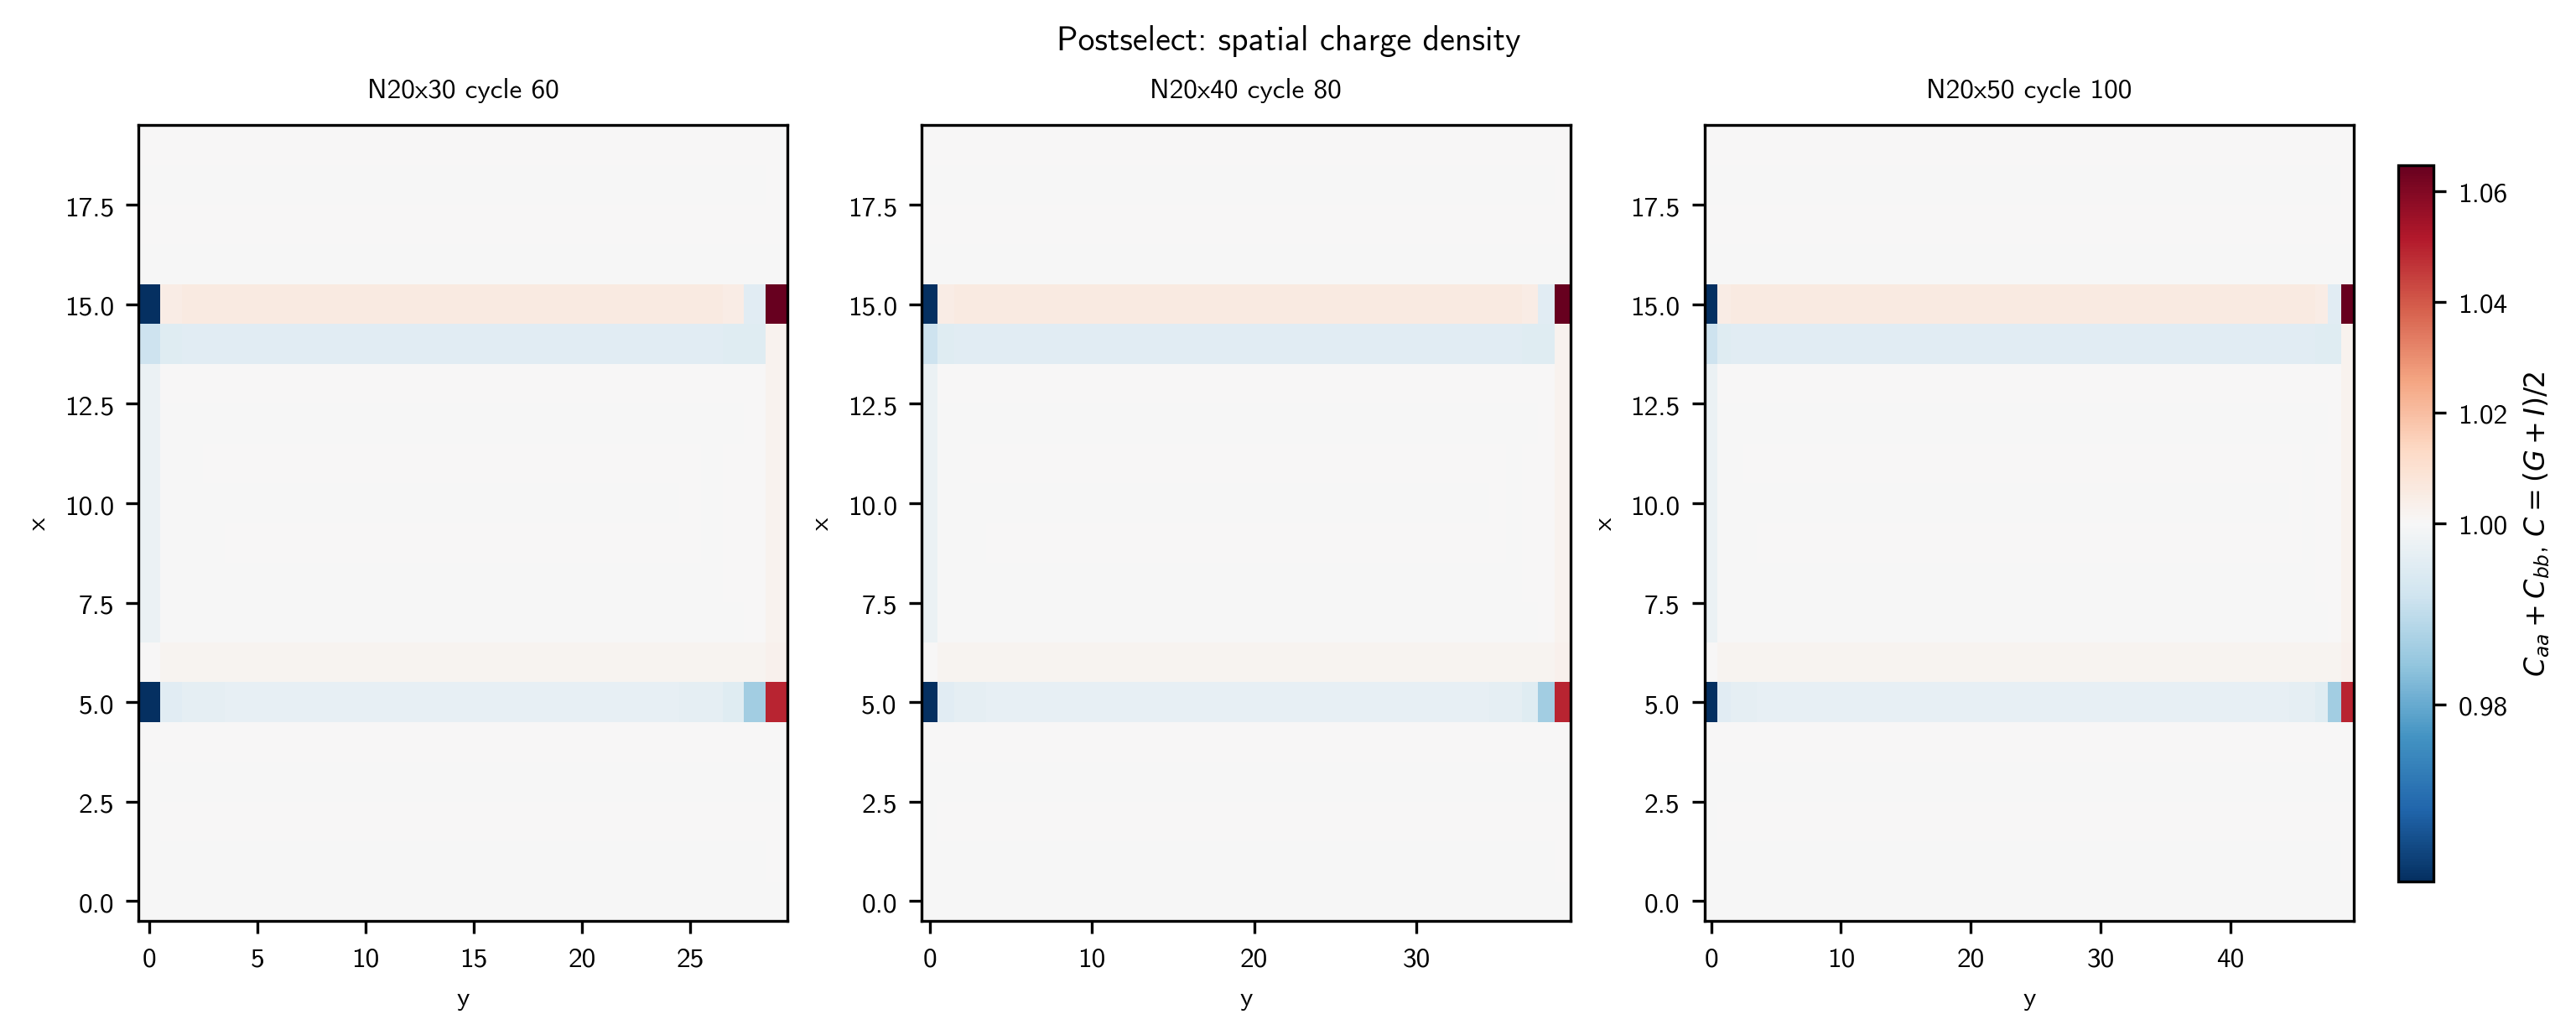

In [15]:
if RUN_POSTSELECT_CHARGE_VIDEO:
    from matplotlib.animation import FFMpegWriter, FuncAnimation
    from matplotlib import colors as mcolors

    _PS_FRAME_REPEAT = 3
    _PS_FPS = pthv.FPS

    # local_charge_cell_mean_avg shape: (cycles, Nx, Ny) — single-trajectory field
    _all_charge = np.concatenate(
        [r["local_charge_cell_mean_avg"].ravel() for r in post_centered_charge_records]
    )
    _vmin, _vmax = float(_all_charge.min()), float(_all_charge.max())
    _vcenter = 1.0   # half-filled = 1 charge per cell (2 modes)
    _vcenter = float(np.clip(_vcenter, _vmin + 1e-9, _vmax - 1e-9))
    _charge_norm = mcolors.TwoSlopeNorm(vmin=_vmin, vcenter=_vcenter, vmax=_vmax)

    _max_cycles = max(int(r["cycles"]) for r in post_centered_charge_records)
    _total_frames = _max_cycles * _PS_FRAME_REPEAT

    _ps_charge_video_path = postselect_figure_root / "postselect_spatial_charge_mean_video.mp4"
    _ps_charge_final_frame_path = postselect_figure_root / "postselect_spatial_charge_mean_final_frame.png"

    _video_figsize = pthv._even_canvas_figsize(pthv.HEATMAP_VIDEO_FIGSIZE, pthv.VIDEO_DPI)

    with plt.rc_context(pthv._style_context()):
        _fig, _axes = plt.subplots(
            1, len(post_centered_charge_records),
            figsize=_video_figsize,
            constrained_layout=True,
        )
        _axes = np.atleast_1d(_axes)
        _images = []
        for _ax, _rec in zip(_axes, post_centered_charge_records):
            _im = _ax.imshow(
                _rec["local_charge_cell_mean_avg"][0],
                origin="lower", aspect="auto",
                cmap="RdBu_r", norm=_charge_norm, interpolation="nearest",
            )
            _ax.set_xlabel("y")
            _ax.set_ylabel("x")
            _images.append(_im)
        _fig.suptitle("Postselect: spatial charge density")
        _cb = _fig.colorbar(_images[-1], ax=list(_axes), pad=0.02, shrink=0.9)
        _cb.set_label(r"$C_{aa}+C_{bb}$, $C=(G+I)/2$")

        def _ps_update(frame_idx):
            artists = []
            for _ax, _rec, _im in zip(_axes, post_centered_charge_records, _images):
                _cycle_idx = min(frame_idx // _PS_FRAME_REPEAT, int(_rec["cycles"]) - 1)
                _im.set_data(_rec["local_charge_cell_mean_avg"][_cycle_idx])
                _ax.set_title(f"N{_rec['Nx']}x{_rec['Ny']} cycle {_cycle_idx + 1}", pad=8)
                artists += [_im, _ax.title]
            return artists

        _ps_update(0)
        _writer = FFMpegWriter(
            fps=_PS_FPS, codec="libx264", bitrate=2200,
            extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"],
        )
        _anim = FuncAnimation(_fig, _ps_update, frames=_total_frames, interval=1000 / _PS_FPS, blit=False)
        _anim.save(_ps_charge_video_path, writer=_writer, dpi=pthv.VIDEO_DPI)

        _ps_update(_total_frames - 1)
        _fig.savefig(_ps_charge_final_frame_path, dpi=pthv.PNG_DPI, bbox_inches="tight")
        plt.close(_fig)

    display_video_if_exists("Postselect: Spatial Charge Density Video", _ps_charge_video_path)
    display_image_if_exists("Postselect: Spatial Charge Density — Final Frame", _ps_charge_final_frame_path)

In [16]:
# figures and videos displayed inline in generation cells above